# **Loan Approval Prediction**

---

**Name** : Aslam Rahman P A

**Organization** : Entri Elevate

**Date** : 15.04.2025

-----

##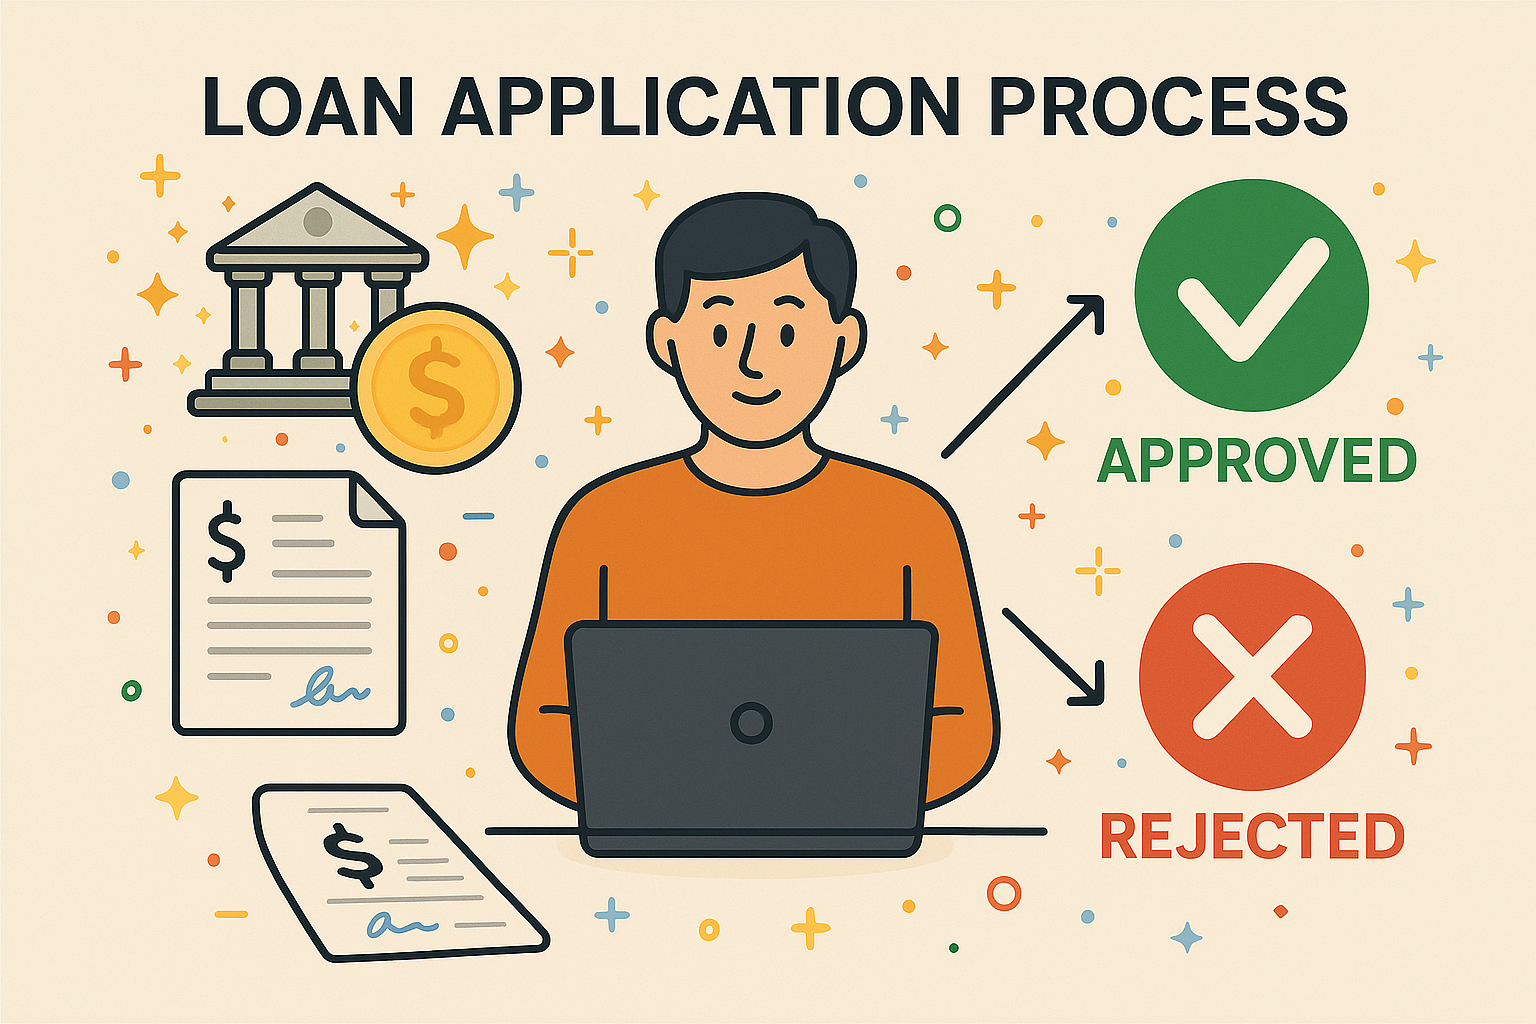


# **Overview of Problem Statement:**
Financial institutions face a significant challenge in assessing the creditworthiness of loan applicants efficiently and accurately. Traditional loan approval processes often rely on manual evaluation, which can be time-consuming, inconsistent, and prone to human bias.

The goal of this project is to develop a machine learning-based system that can predict whether a loan should be approved or rejected based on applicant data. This includes factors such as income, employment type, credit history, loan amount, interest rate, and other relevant financial indicators.This project not only enhances operational efficiency but also supports data-driven decision making in financial services, ensuring fairness, accuracy, and improved customer satisfaction.




---




# **🎯 Objective:**
This dataset is used to build machine learning models that predict whether a loan application will be approved or rejected based on applicant information

# **Data Description:**
# Source:
data set link:https://www.kaggle.com/code/mhmedgaber/loan-approval-classification-eda-accuracy-93?scriptVersionId=228335629&cellId=2

# **📊 Loan Approval Dataset 📊**
A comprehensive dataset for loan approval prediction
📝 Dataset Overview
The dataset contains 45,000 records and 14 variables, each described below:  

| **Variable**                  | **Description**                                  | **Type**        |
|-------------------------------|------------------------------------------------|----------------|
| `person_age`                  | Age of the person                              | Float          |
| `person_gender`               | Gender of the person                           | Categorical   |
| `person_education`            | Highest education level                        | Categorical   |
| `person_income`               | Annual income                                  | Float          |
| `person_emp_exp`              | Years of employment experience                 | Integer        |
| `person_home_ownership`       | Home ownership status (e.g., rent, own, mortgage) | Categorical   |
| `loan_amnt`                   | Loan amount requested                          | Float          |
| `loan_intent`                 | Purpose of the loan                            | Categorical   |
| `loan_int_rate`               | Loan interest rate                             | Float          |
| `loan_percent_income`         | Loan amount as a percentage of annual income   | Float          |
| `cb_person_cred_hist_length`  | Length of credit history in years              | Float          |
| `credit_score`                | Credit score of the person                     | Integer        |
| `previousLoanDefaultsOnFile`  | Indicator of previous loan defaults            | Categorical   |
| `loan_status` (🎯 **Target**) | Loan approval status: `1` = approved, `0` = rejected | Integer |


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/LOAN.csv")
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,male,Associate,47971,6,RENT,15000,MEDICAL,15.66,0.31,3,645,No,1
44996,37,female,Associate,65800,17,RENT,9000,HOMEIMPROVEMENT,14.07,0.14,11,621,No,1
44997,33,male,Associate,56942,7,RENT,2771,DEBTCONSOLIDATION,10.02,0.05,10,668,No,1
44998,29,male,Bachelor,33164,4,RENT,12000,EDUCATION,13.23,0.36,6,604,No,1


In [ ]:
# Display the number of rows and columns
print("The Number of Rows :", df.shape[0])
print("The Number of Columns :", df.shape[1])

The Number of Rows : 45000
The Number of Columns : 14


In [ ]:
# Map numerical values to categorical values
df['loan_status'] = df['loan_status'].map({0: 'No', 1: 'Yes'})

# Check the updated column
print(df['loan_status'].head())

0    Yes
1     No
2    Yes
3    Yes
4    Yes
Name: loan_status, dtype: object


0 is replaced with 'No' (Loan Rejected)

1 is replaced with 'Yes' (Loan Approved)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000


# **DATA PREPROCESSING**

## **Step 1: Handling Missing Values**

In [ ]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
df.isnull().mean()*100

,0
person_age,0.0
person_gender,0.0
person_education,0.0
person_income,0.0
person_emp_exp,0.0
person_home_ownership,0.0
loan_amnt,0.0
loan_intent,0.0
loan_int_rate,0.0
loan_percent_income,0.0


**There is no missing values.**

## **Step 2: Handling Duplicates**

In [ ]:
df.duplicated().sum()

np.int64(0)

**There is no duplicated values.**

## **Step 3: Handling Skewness**

In [ ]:
num = df.select_dtypes(include="number").skew()
num

,0
person_age,2.548154
person_income,34.137583
person_emp_exp,2.594917
loan_amnt,1.179731
loan_int_rate,0.213784
loan_percent_income,1.034512
cb_person_cred_hist_length,1.631720
credit_score,-0.610261


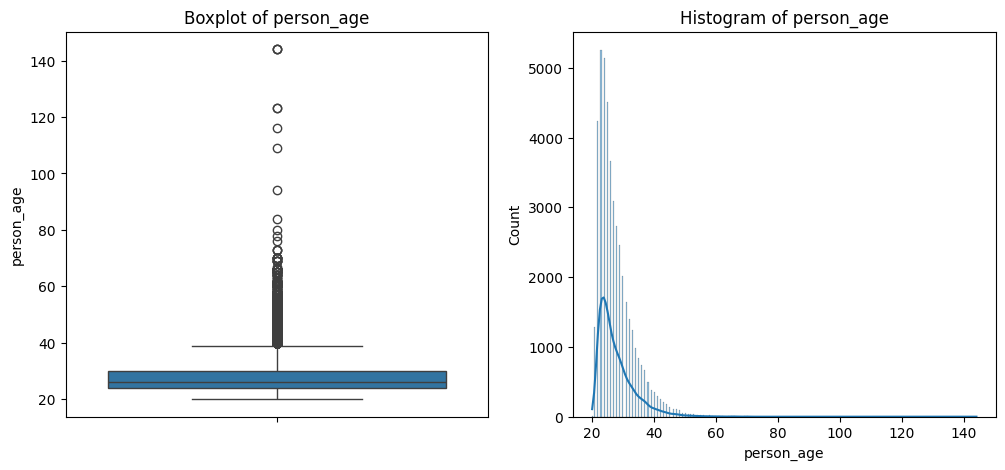

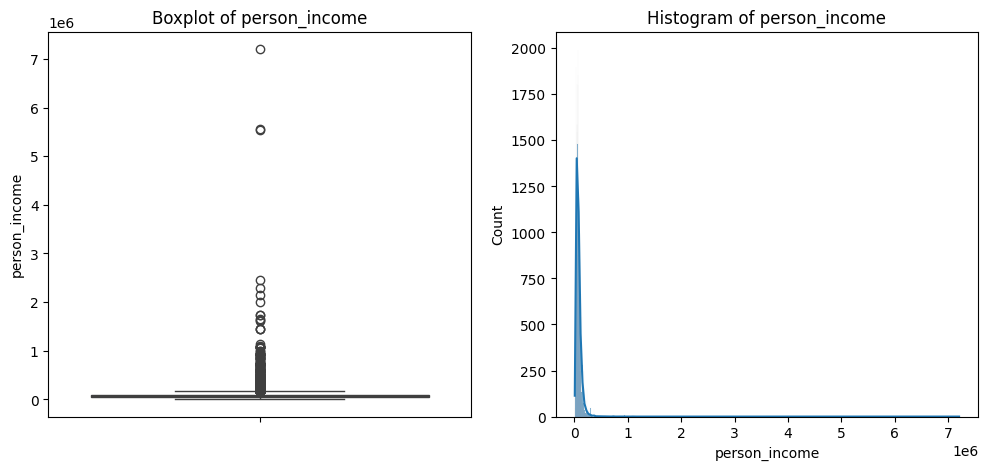

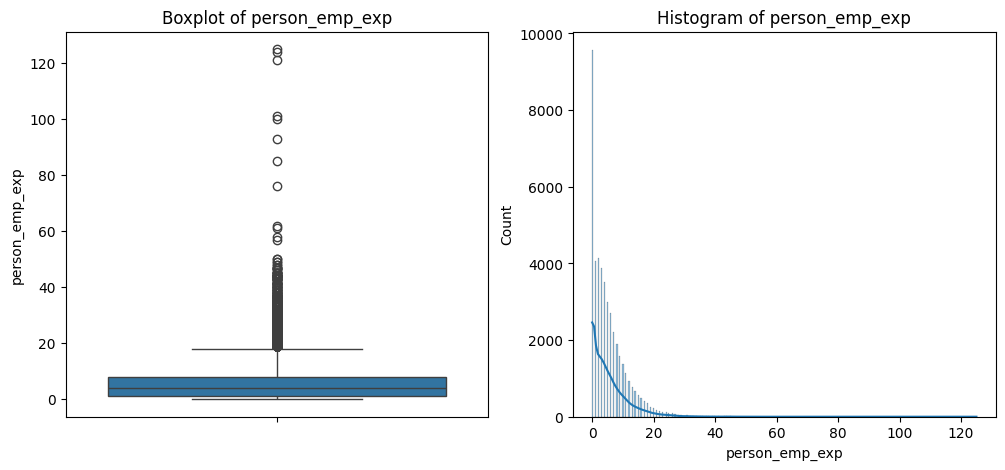

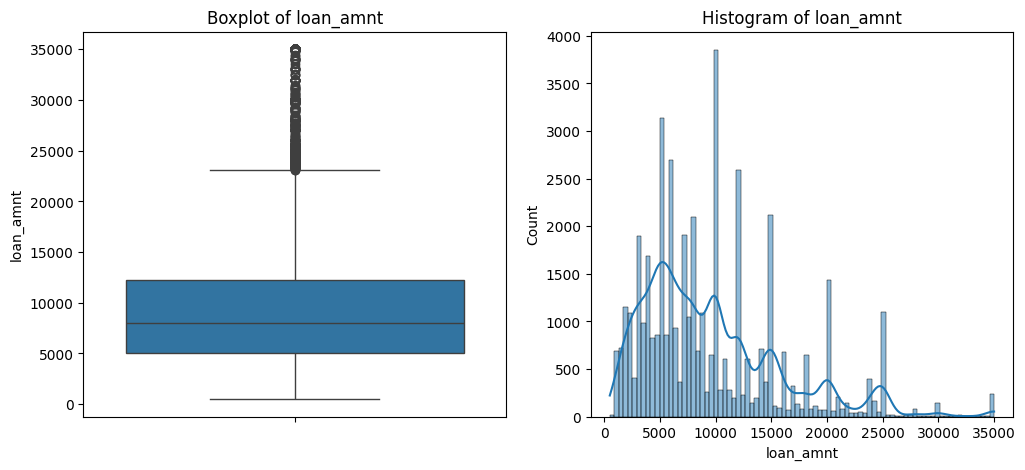

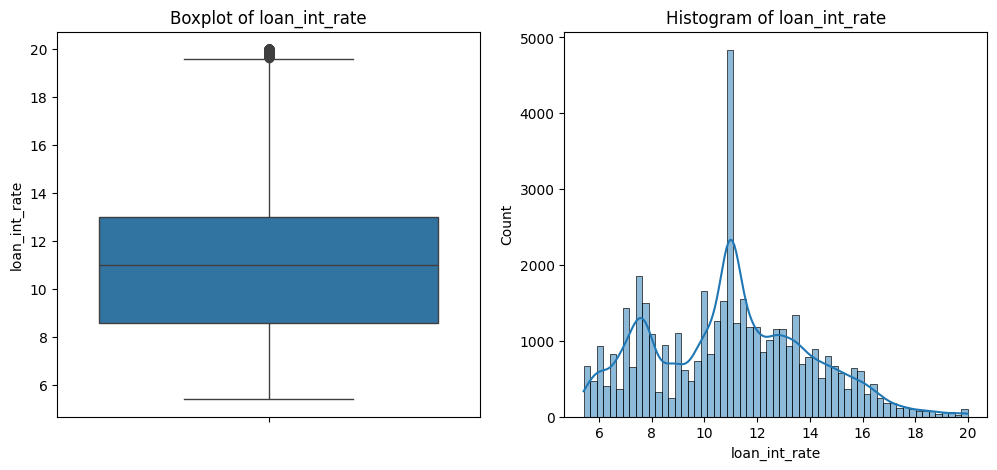

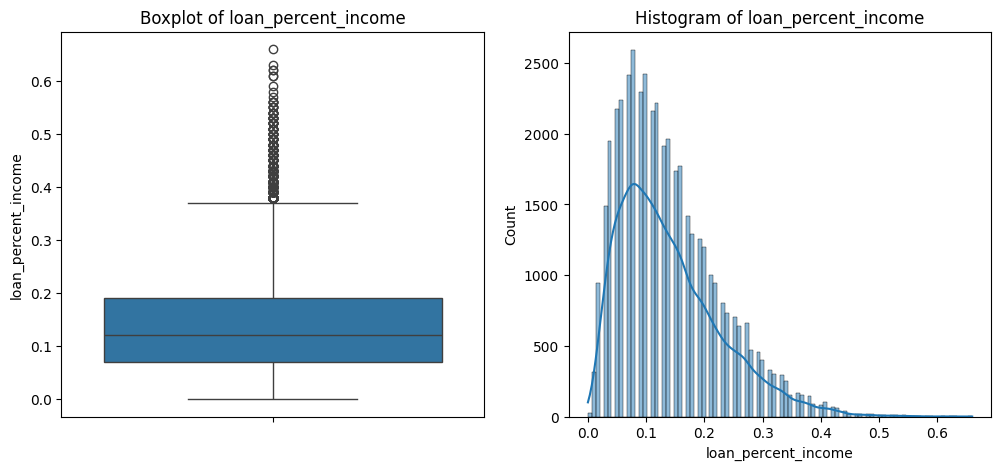

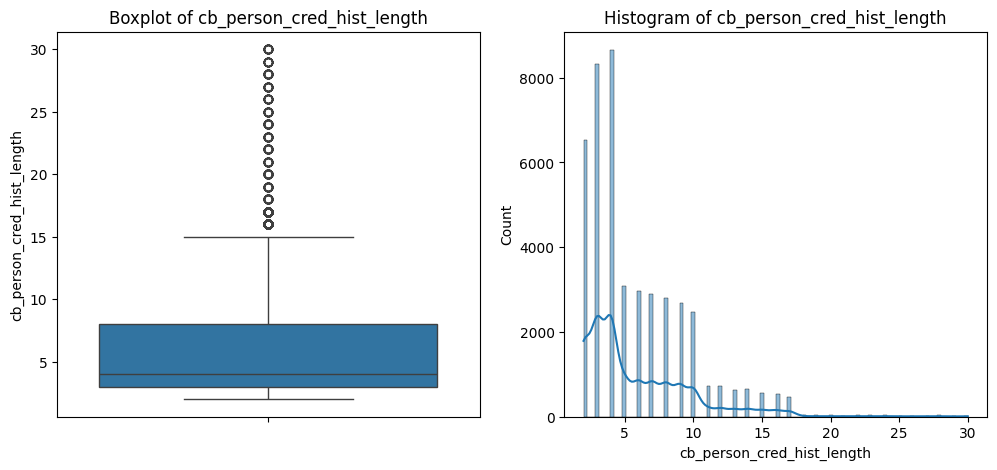

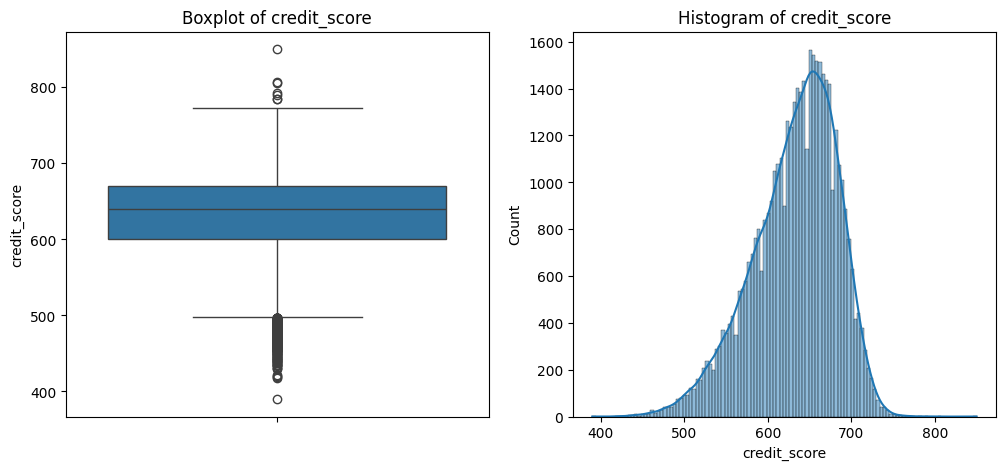

In [ ]:
 # Boxplot
 numerical_columns = df.select_dtypes(include=['int64','float64'])
 for column in numerical_columns:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
 #histplot
    plt.subplot(1, 2, 2)
    sns.histplot(df[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.show()


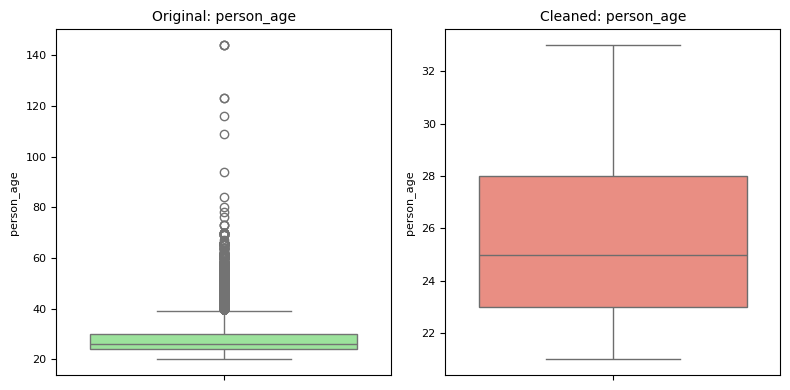

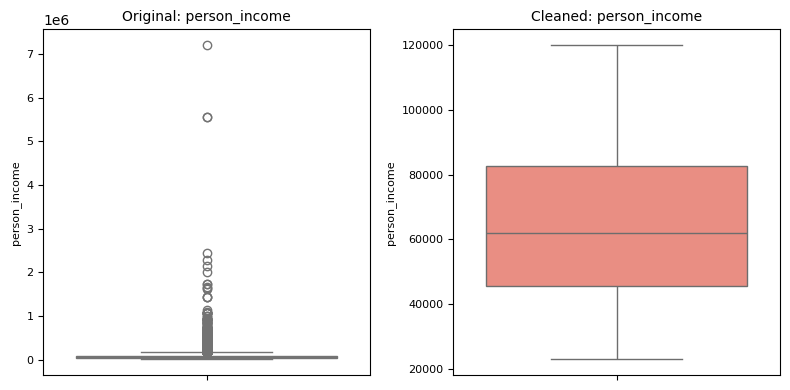

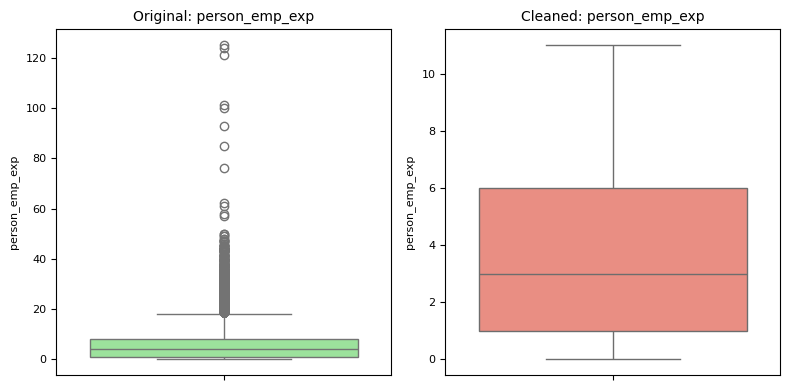

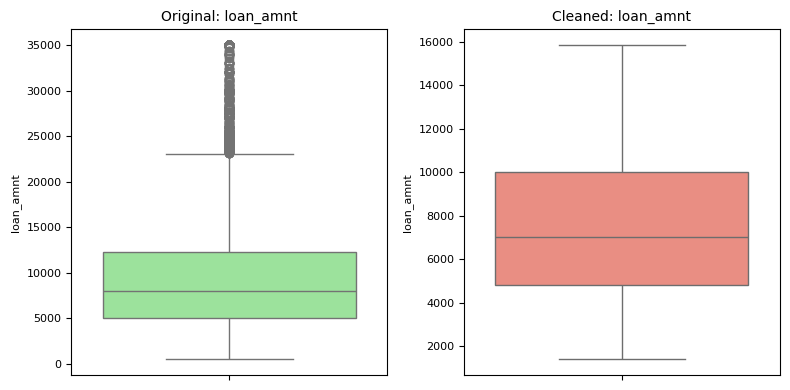

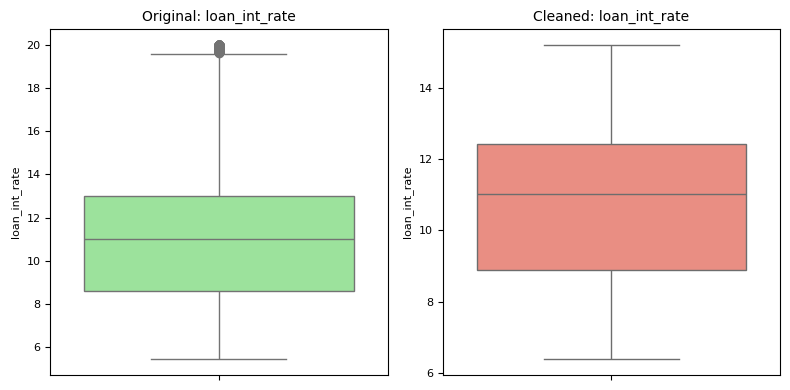

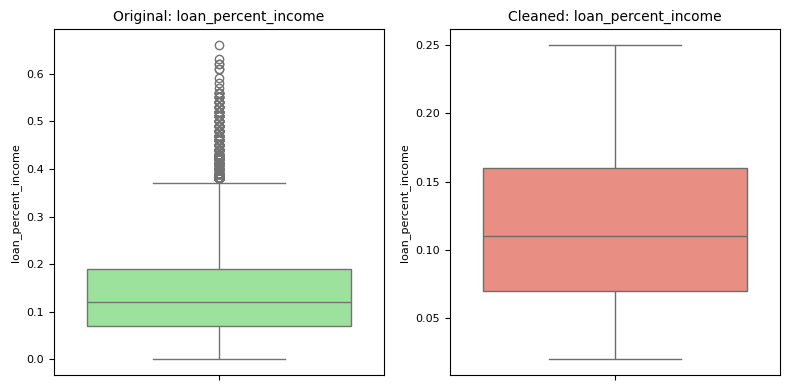

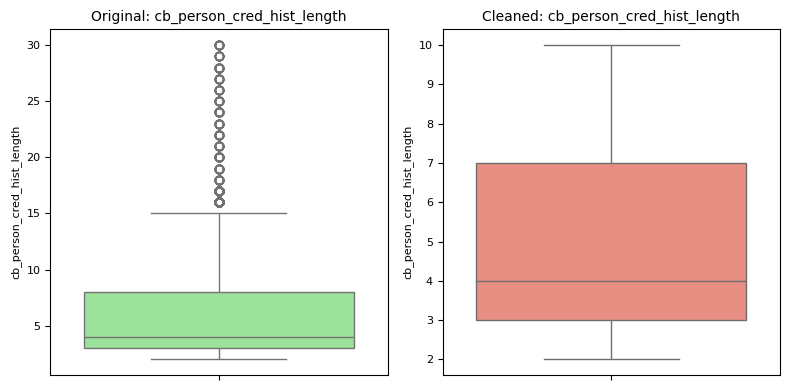

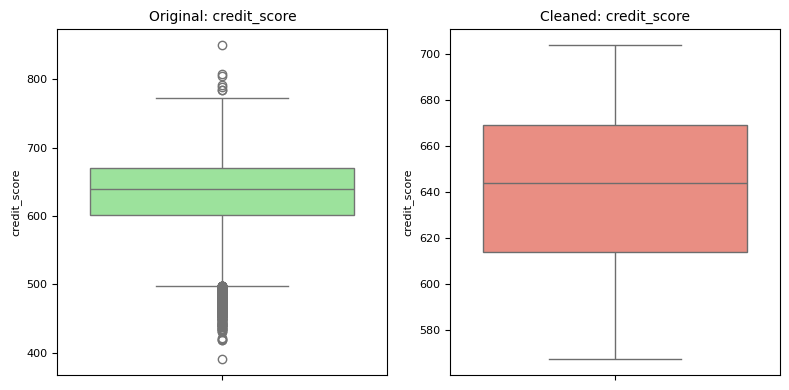

Dataset shape before removing outliers: (45000, 14)
Dataset shape after removing outliers: (37940, 14)


In [ ]:
# Assuming df is your DataFrame and numerical_columns is a list of numerical columns
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Create a copy of the original DataFrame to avoid modifying it
data_cleaned = df.copy()

# Iterate through numerical columns
for column in numerical_columns:
    # Calculate Q1, Q3, and IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 0.5 * IQR
    upper = Q3 + 0.5 * IQR

    # Filter data to remove outliers for the current column
    data_cleaned = df[(df[column] >= lower) & (df[column] <= upper)]

    # Create a box plot for the original data
    plt.figure(figsize=(8, 4))  # Smaller figure size
    plt.subplot(1, 2, 1)
    sns.boxplot(y=df[column], color='lightgreen')
    plt.title(f'Original: {column}', fontsize=10)  # Smaller title font
    plt.ylabel(column, fontsize=8)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

    # Create a box plot for the cleaned data
    plt.subplot(1, 2, 2)
    sns.boxplot(y=data_cleaned[column], color='salmon')
    plt.title(f'Cleaned: {column}', fontsize=10)  # Smaller title font
    plt.ylabel(column, fontsize=8)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

    # Show plots
    plt.tight_layout()
    plt.show()

# Print the shape of the dataset before and after removing outliers
print("Dataset shape before removing outliers:", df.shape)
print("Dataset shape after removing outliers:", data_cleaned.shape)

**The IQR method was used to identify and remove outliers, reducing the dataset size from 45,000 rows to 37,940 rows, with 7,060 outliers removed. This process improved the dataset's quality by eliminating extreme values, ensuring a more reliable and representative dataset for analysis.**

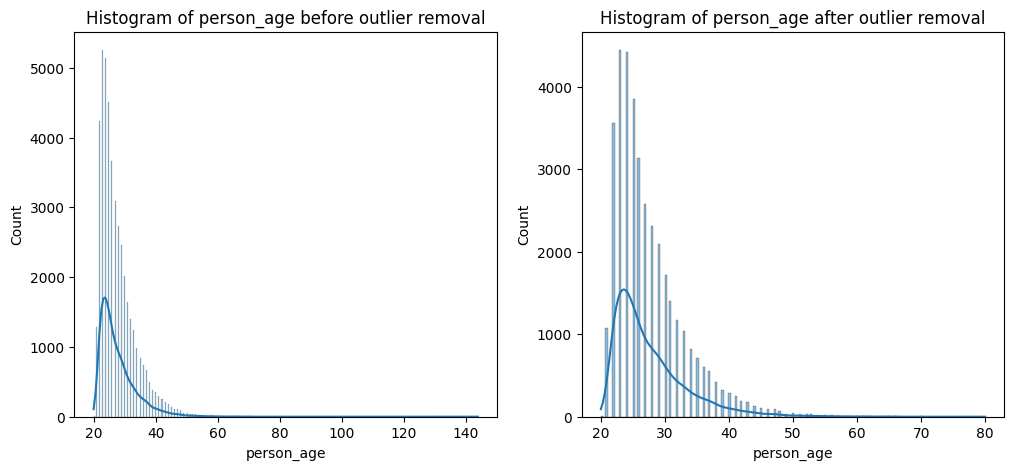

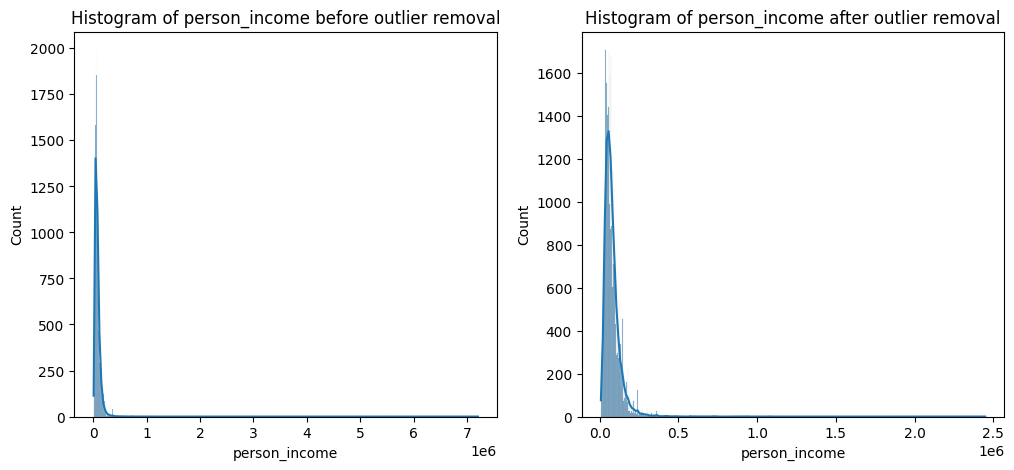

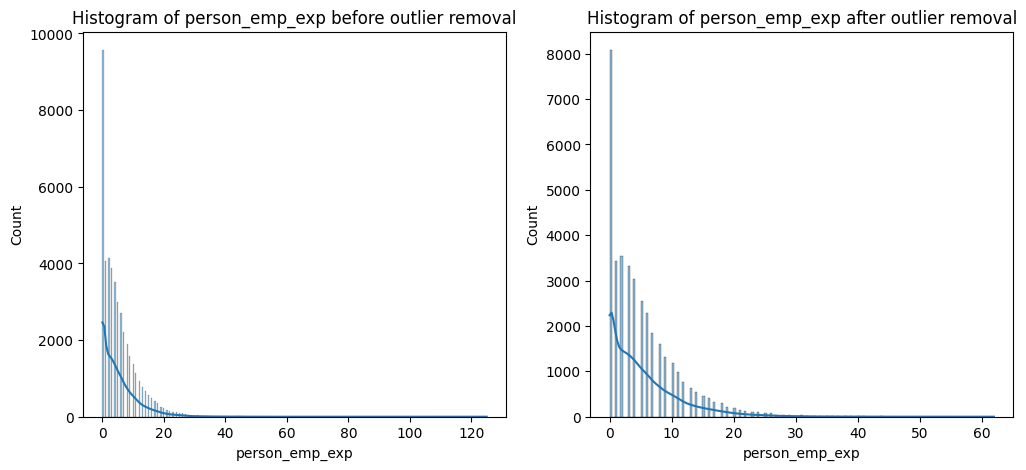

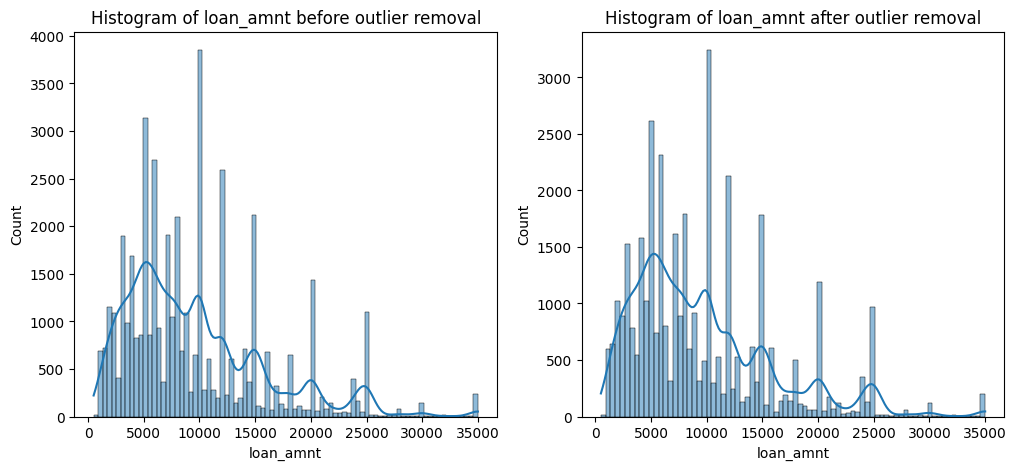

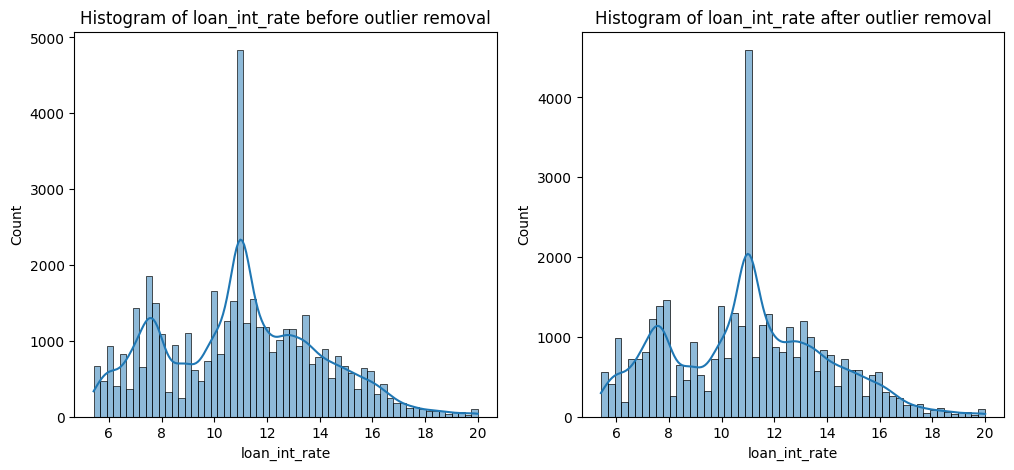

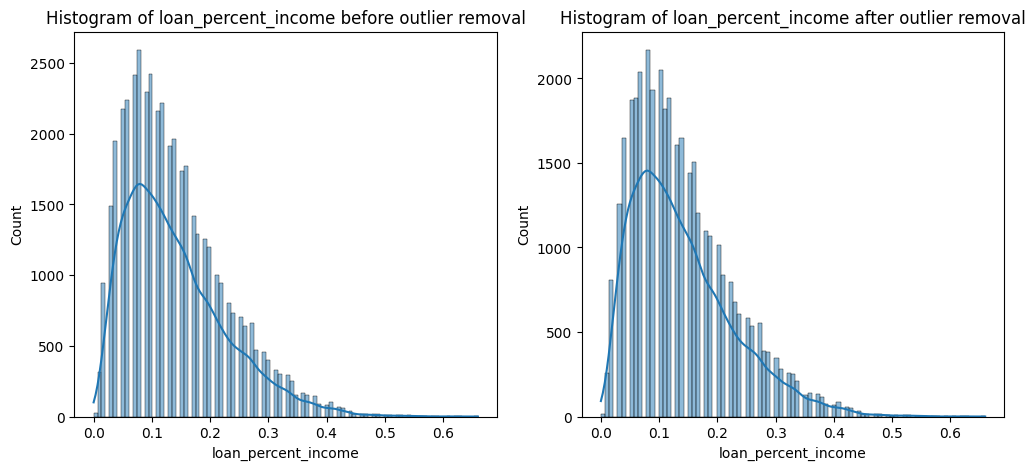

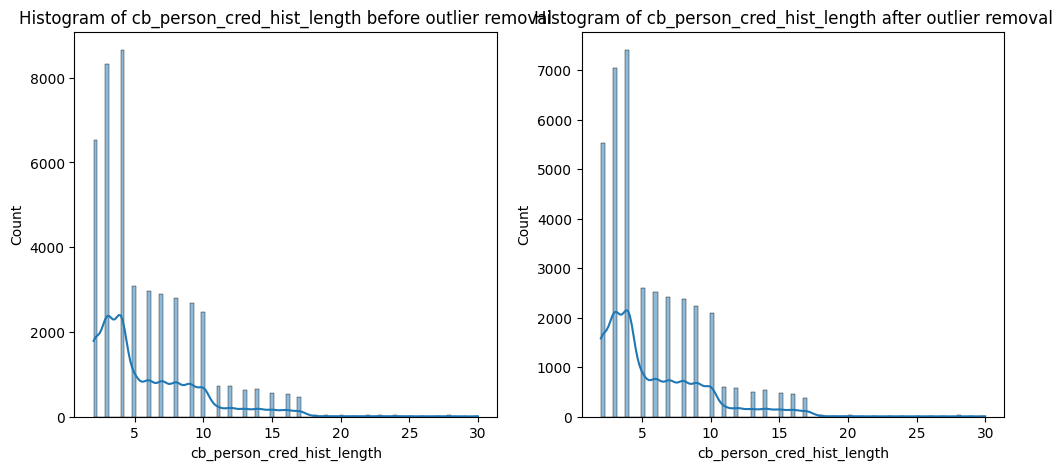

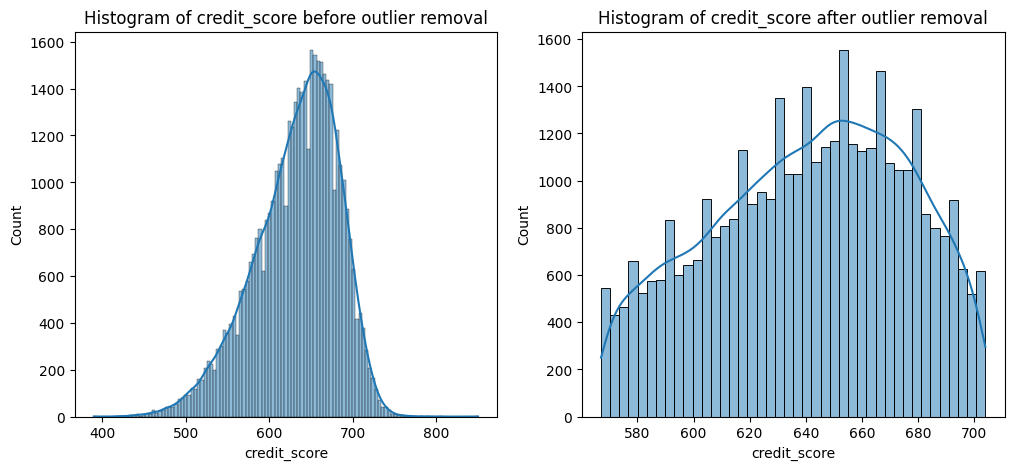

In [ ]:
for column in numerical_columns:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Histogram of {column} before outlier removal')

    # Histogram
    plt.subplot(1, 2, 2)
    sns.histplot(data_cleaned[column],kde=True)
    plt.title(f'Histogram of {column} after outlier removal')

    plt.show()

In [ ]:
numerical_features = data_cleaned.select_dtypes(include = ['int64','float64']).columns
print('\nSkewness of all the features:\n')
print(data_cleaned[numerical_features].skew())



Skewness of all the features:

person_age                    1.788187
person_income                 9.658712
person_emp_exp                1.822120
loan_amnt                     1.178664
loan_int_rate                 0.220333
loan_percent_income           1.035529
cb_person_cred_hist_length    1.609055
credit_score                 -0.223802
dtype: float64


In [ ]:
# Highlight the features with high skewness (greater than 0.5 or less than -0.5)
from scipy.stats import skew
skewness = data_cleaned[numerical_features].apply(lambda x: skew(x))
skewed_feature = skewness[(skewness > 0.5)|(skewness < -0.5)].index
print("Highly Skewed Features:\n",skewness[skewed_feature])

Highly Skewed Features:
 person_age                    1.788116
person_income                 9.658330
person_emp_exp                1.822048
loan_amnt                     1.178617
loan_percent_income           1.035488
cb_person_cred_hist_length    1.608991
dtype: float64


**After removing outliers there are still some positive outliers.**

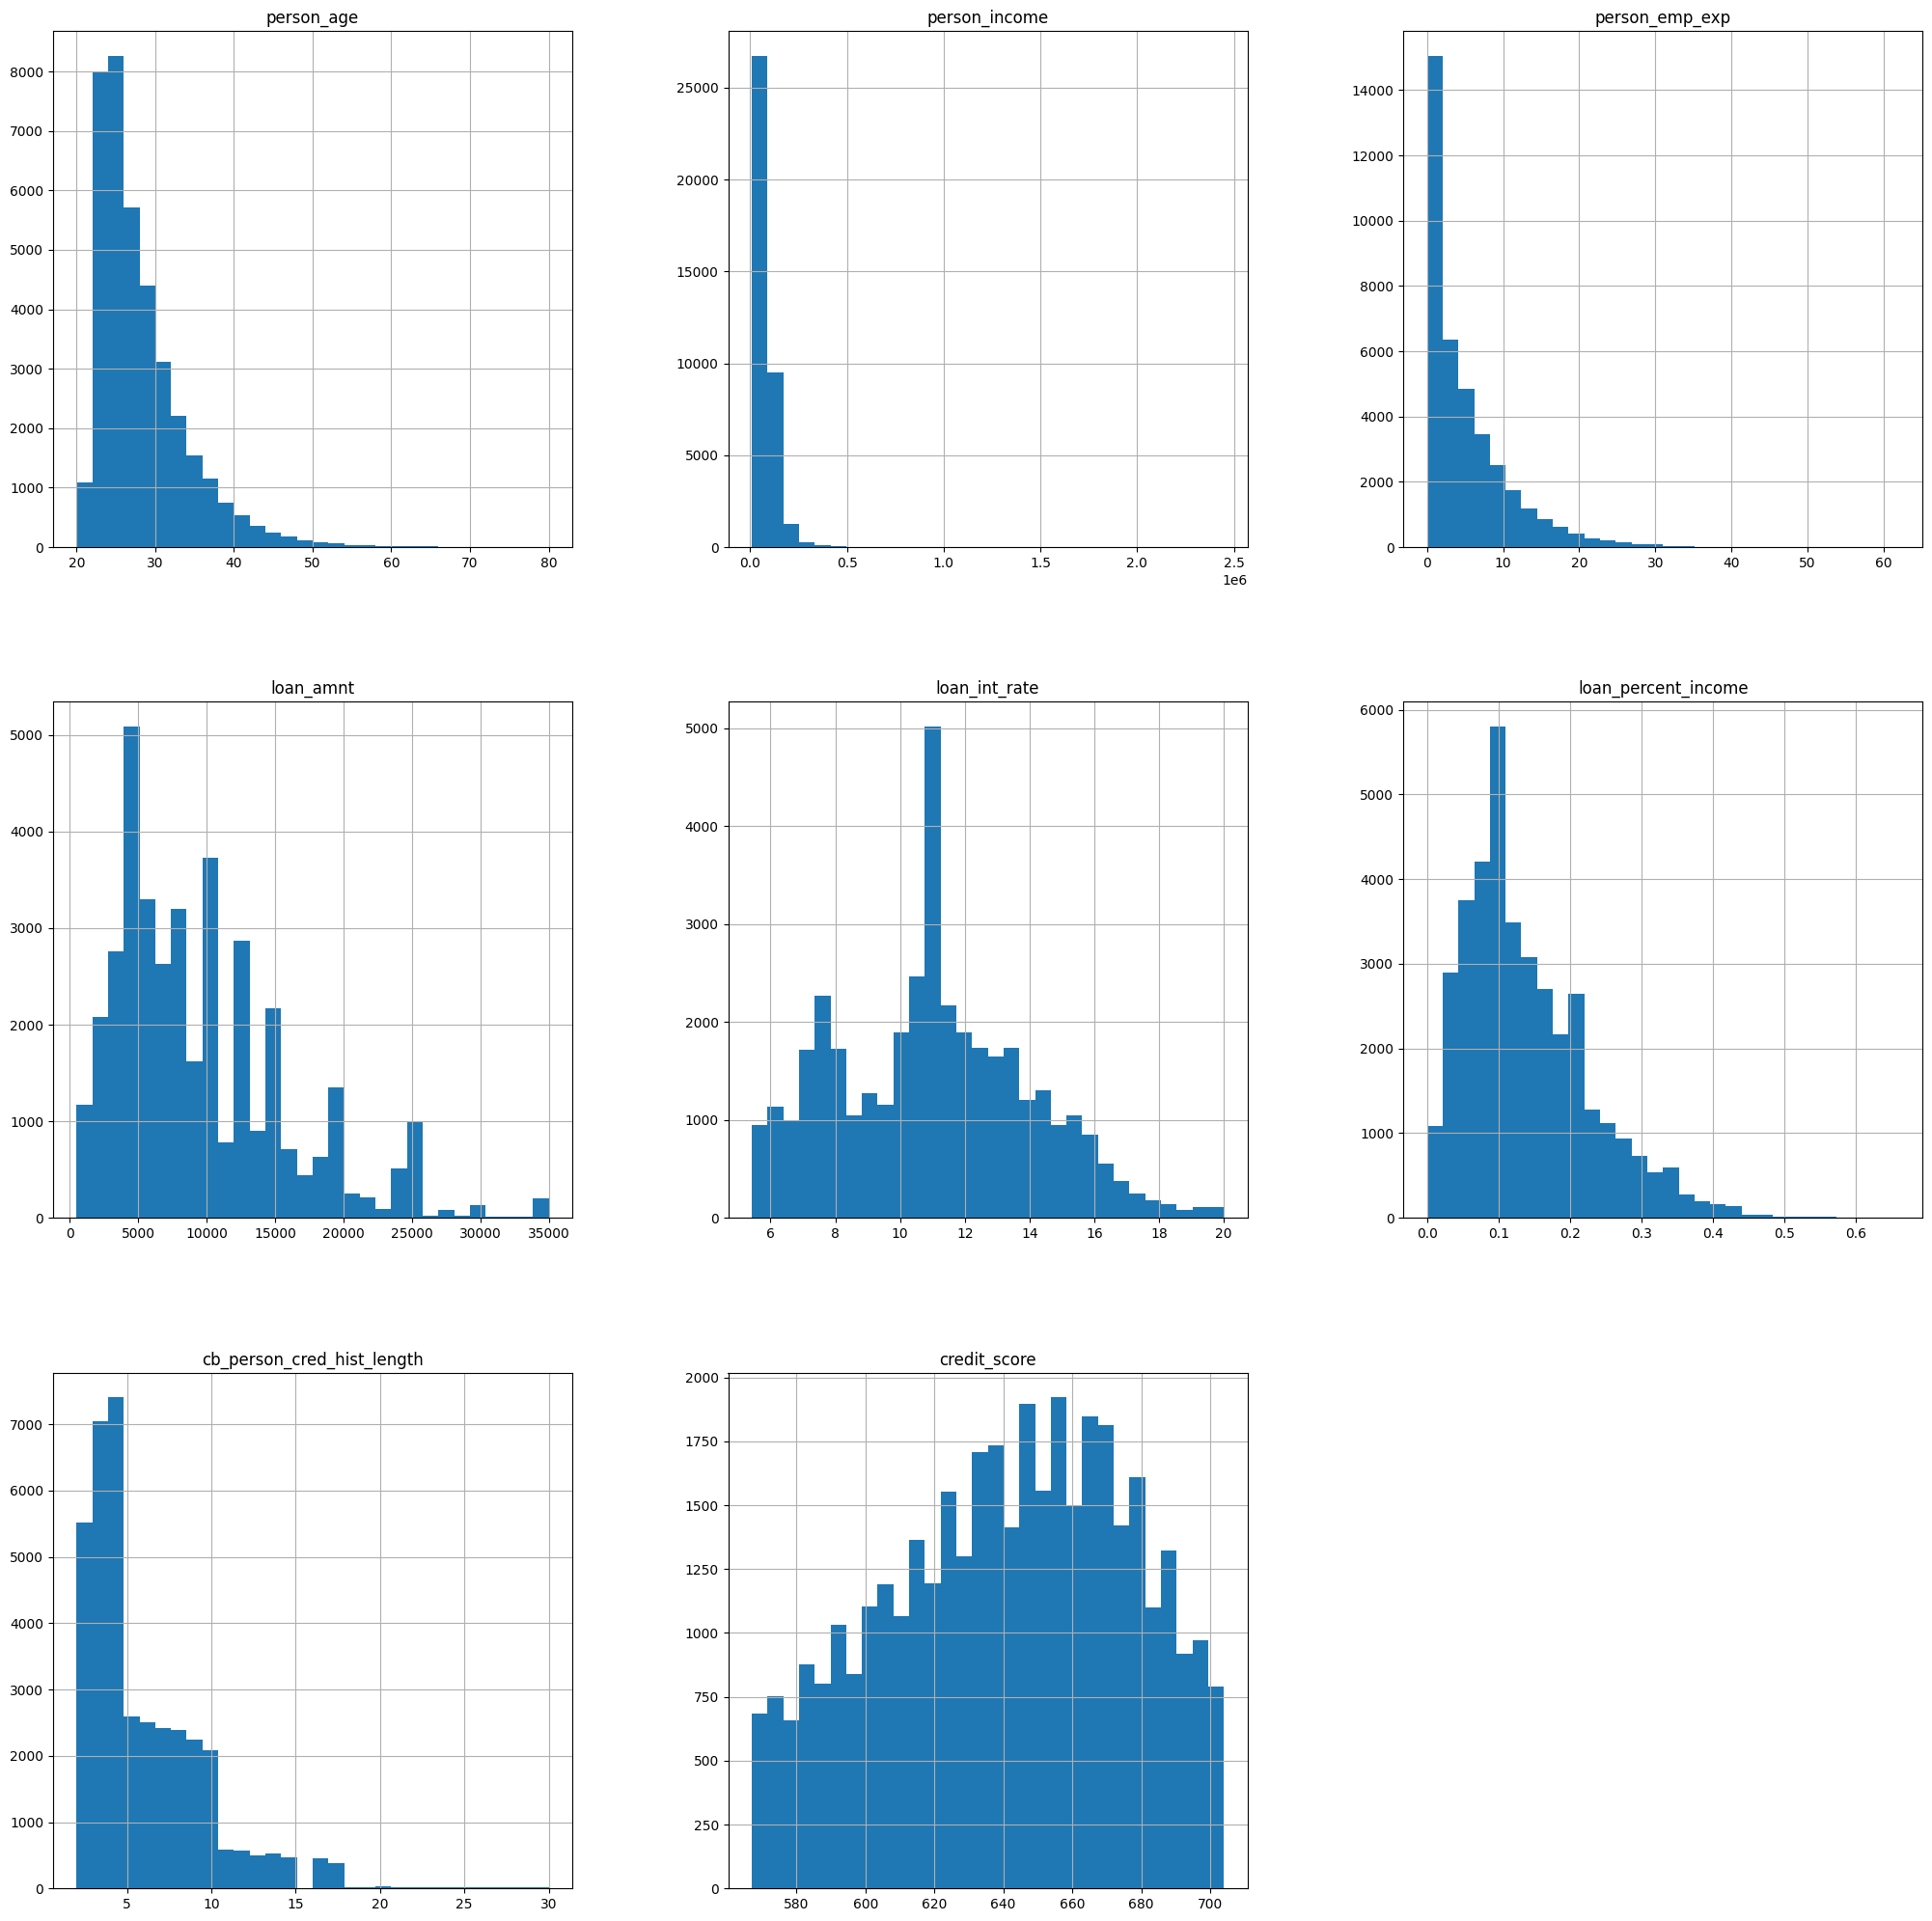

In [ ]:
# Ploting Histogram before transformation
data_cleaned.hist(figsize=(25,25),bins = 30)
plt.show()

In [ ]:
# Applying Yoe-Johnson transformation for removing positive outliers
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method = 'yeo-johnson')
data_cleaned[skewed_feature] = pt.fit_transform(data_cleaned[skewed_feature])

<ipython-input-17-cc29892689ad>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[skewed_feature] = pt.fit_transform(data_cleaned[skewed_feature])


In [ ]:
# Checking Skewness after transformation
print("Skewness after transformation\n",data_cleaned[skewed_feature].skew())

Skewness after transformation
 person_age                    0.135493
person_income                -0.014034
person_emp_exp               -0.024903
loan_amnt                    -0.021875
loan_percent_income           0.092019
cb_person_cred_hist_length    0.072779
dtype: float64


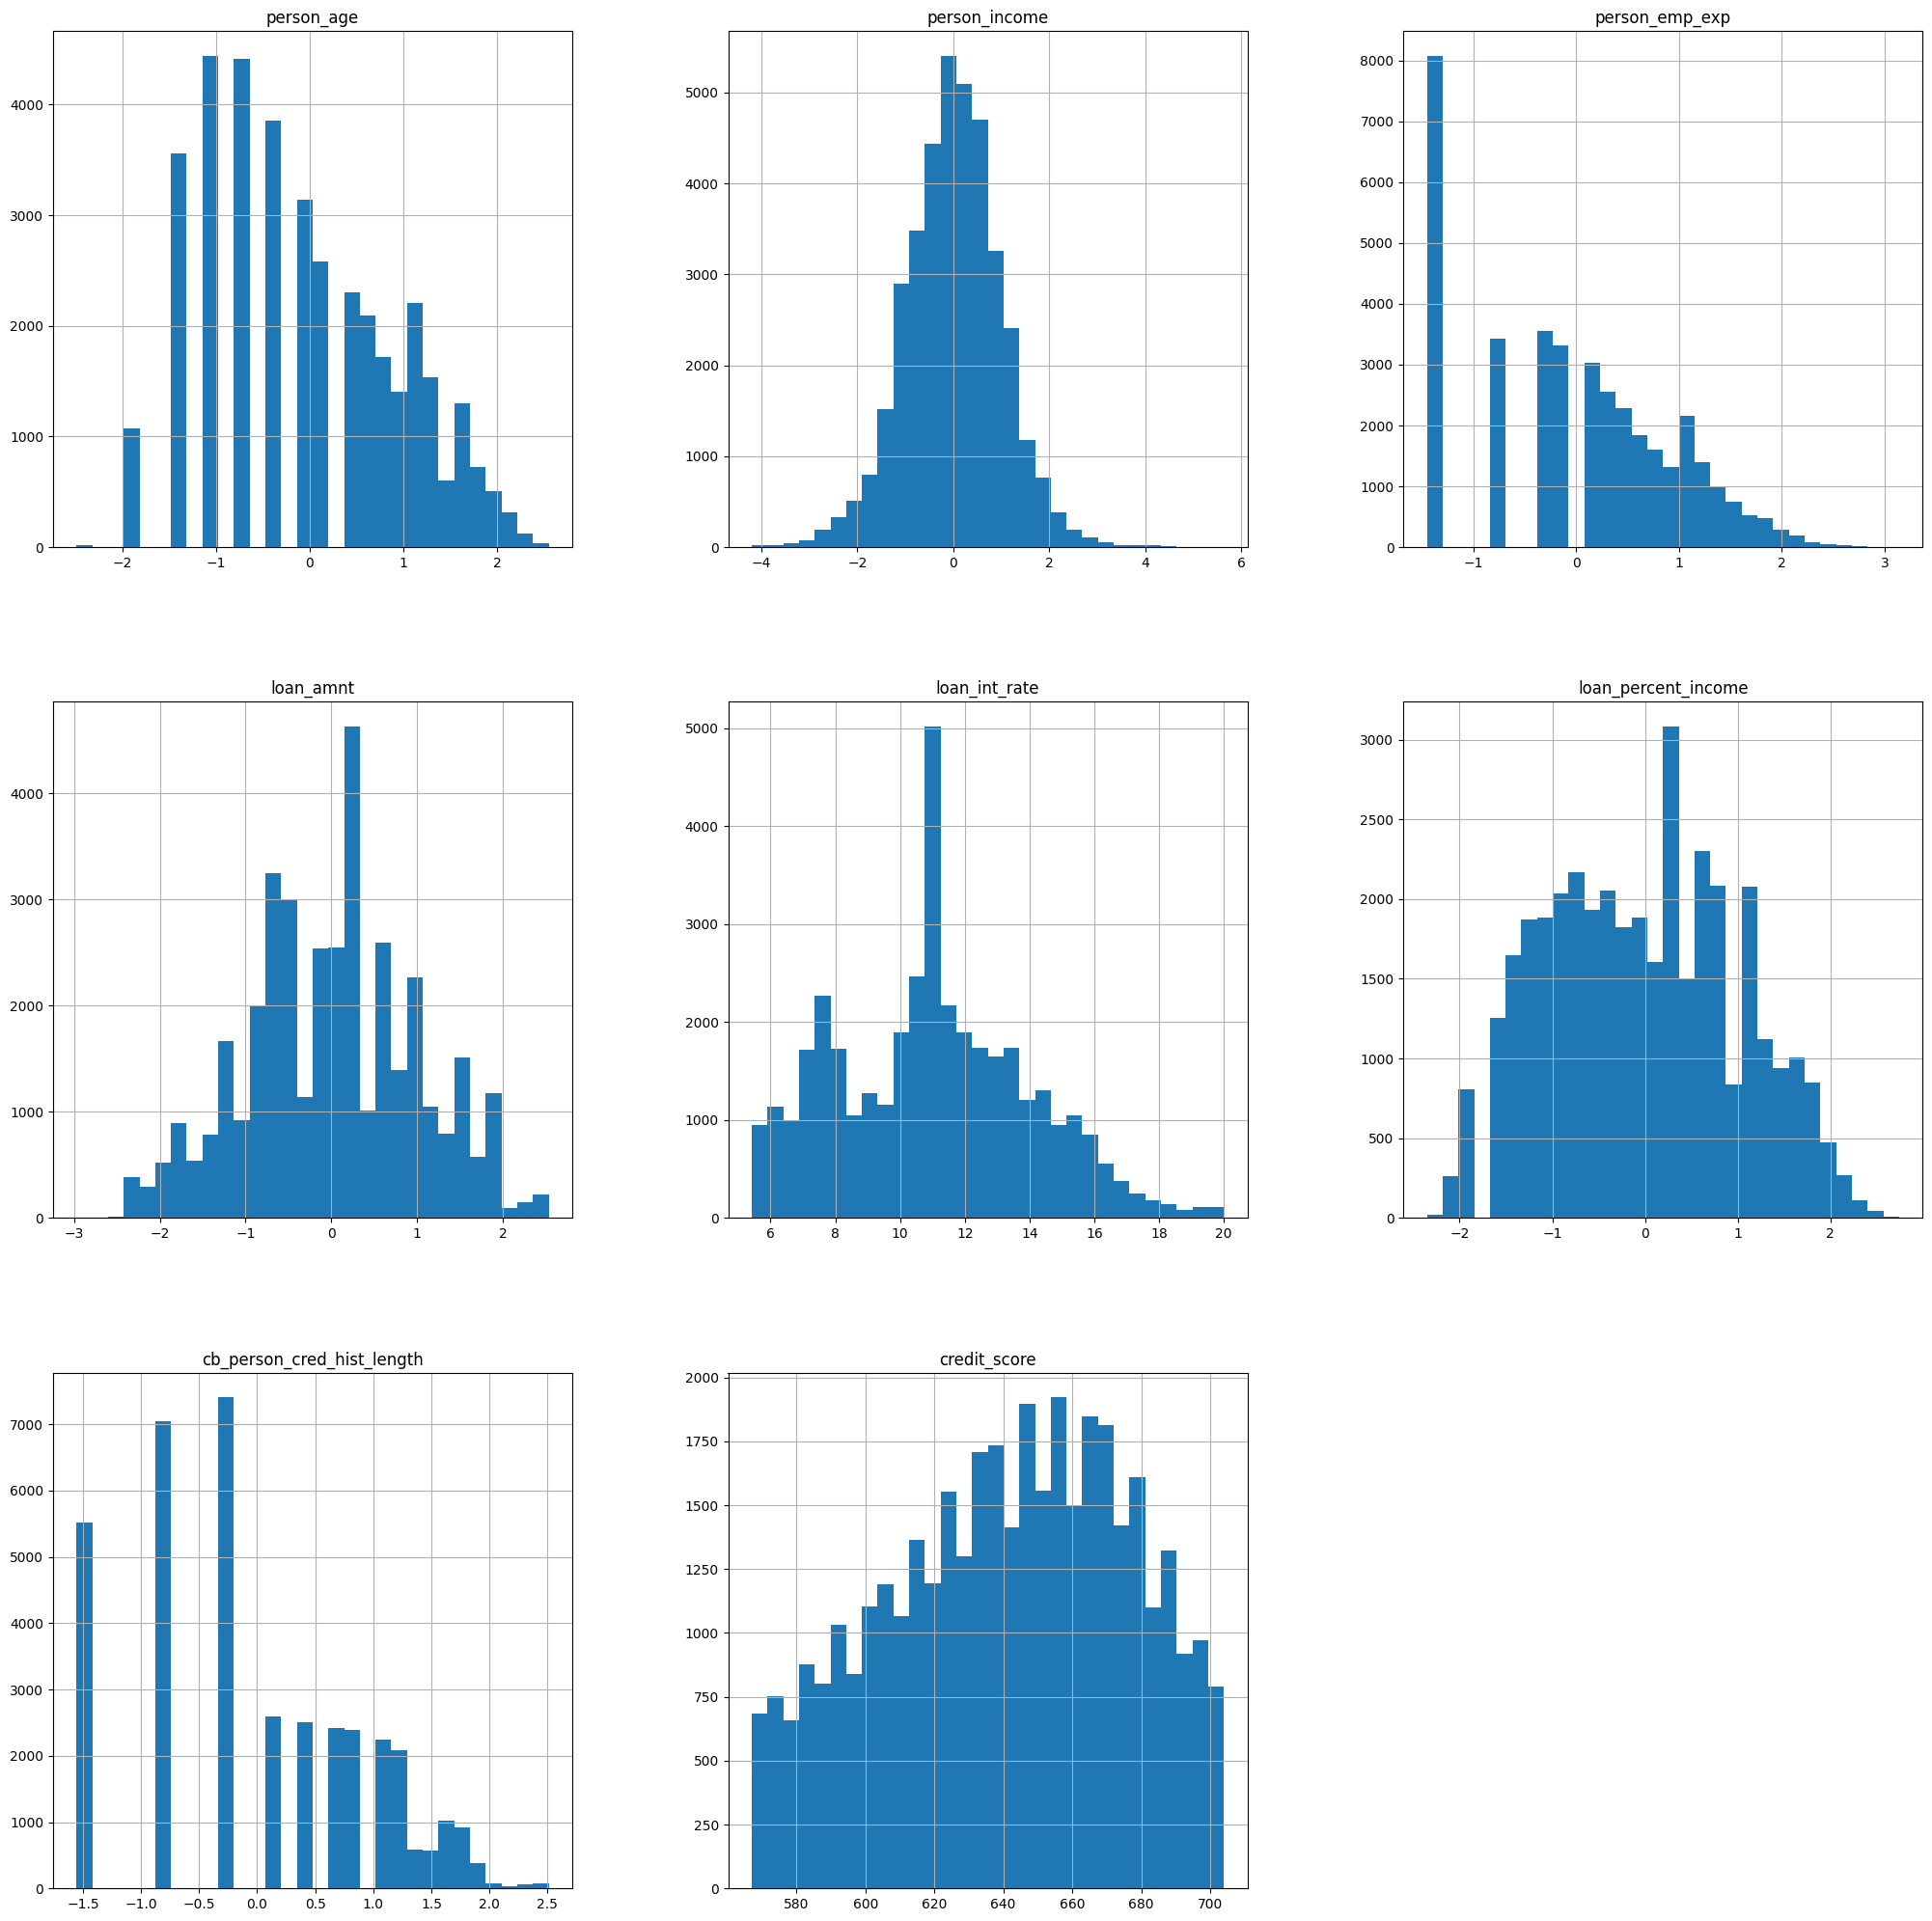

In [ ]:
# Ploting Histogram after transformation
data_cleaned.hist(figsize=(25, 25), bins=30)
plt.show()

# **DATA ANALYSIS**

## **Exploratory Data Analysis**

<ipython-input-64-49500bf66c53>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['loan_intent'],palette="rainbow",width=0.3)


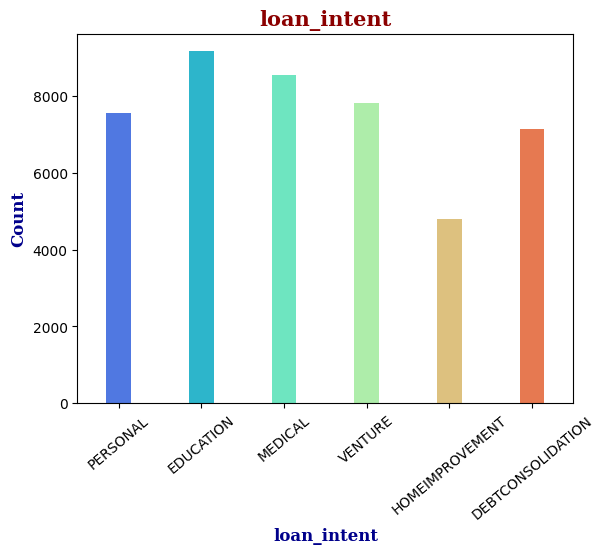

In [ ]:
title_font={"family":"serif","color":"darkred","weight":"bold","size":15}
axis_font={"family":"serif","color":"darkblue","weight":"bold","size":12}
sns.countplot(x=df['loan_intent'],palette="rainbow",width=0.3)
plt.title('loan_intent',fontdict=title_font)
plt.xlabel('loan_intent',fontdict=axis_font)
plt.ylabel('Count',fontdict=axis_font)
plt.xticks(rotation=40)
plt.show()


**Insights**

* Education loans are the most common, followed by Medical and Venture loans.

* Home Improvement loans are the least common purpose among applicants.

* Debt Consolidation and Personal loans have a moderate number of applicants.

<ipython-input-21-6cf00f4b13fc>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["person_home_ownership"],palette="rainbow",width=0.3)


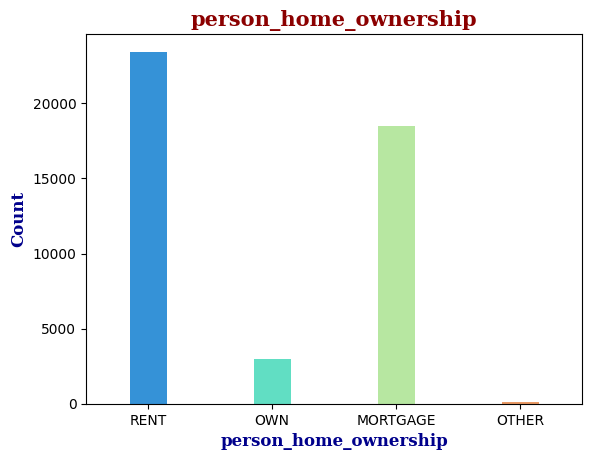

In [ ]:
title_font={"family":"serif","color":"darkred","weight":"bold","size":15}
axis_font={"family":"serif","color":"darkblue","weight":"bold","size":12}
sns.countplot(x=df["person_home_ownership"],palette="rainbow",width=0.3)
plt.title("person_home_ownership",fontdict=title_font)
plt.xlabel("person_home_ownership",fontdict=axis_font)
plt.ylabel('Count',fontdict=axis_font)
plt.show()

**Insights**
* Most loan applicants are renters, followed by those with a mortgage.

* Very few applicants own their homes outright.

* Other types of home ownership are extremely rare.

<ipython-input-79-2d6564f98789>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["person_education"],palette="rainbow",width=0.3)


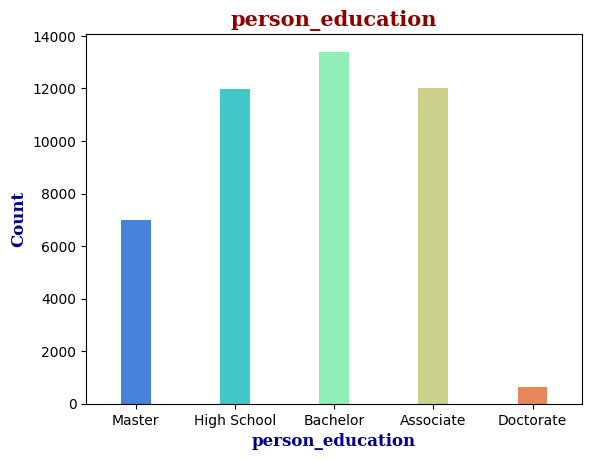

In [ ]:
title_font={"family":"serif","color":"darkred","weight":"bold","size":15}
axis_font={"family":"serif","color":"darkblue","weight":"bold","size":12}
sns.countplot(x=df["person_education"],palette="rainbow",width=0.3)
plt.title("person_education",fontdict=title_font)
plt.xlabel("person_education",fontdict=axis_font)
plt.ylabel('Count',fontdict=axis_font)
plt.show()

**Insights**
* Most loan applicants have a Bachelor’s or Associate’s degree.

* Associate’s degree holders are the second-largest group, slightly ahead of High School graduates

* Master’s degree holders are fewer, and Doctorate holders are very rare.

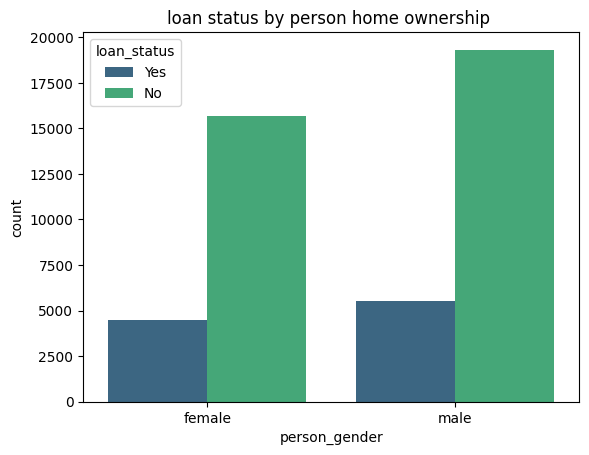

In [ ]:
#countplot to show gender wise loan status
sns.countplot(x="person_gender", hue="loan_status", data=df, palette="viridis")
plt.title("loan status by person home ownership ")
plt.show()


**Insights**

* For both genders, loan rejection (No) counts are much higher than approvals.

* The number of male applicants is higher than females in both approved (Yes) and rejected (No) categories.

In [ ]:
#correlation to check dependencies
correlation_matrix=data_cleaned.select_dtypes("number").corr()
correlation_matrix

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
person_age,1.000000,0.153722,0.877833,0.066734,0.011332,-0.054389,0.813479,0.110068
person_income,0.153722,1.000000,0.130321,0.423795,-0.020867,-0.367053,0.102283,0.015591
person_emp_exp,0.877833,0.130321,1.000000,0.054974,0.016154,-0.047783,0.732574,0.119338
loan_amnt,0.066734,0.423795,0.054974,1.000000,0.120173,0.669676,0.043981,0.002773
loan_int_rate,0.011332,-0.020867,0.016154,0.120173,1.000000,0.131758,0.013851,0.006486
loan_percent_income,-0.054389,-0.367053,-0.047783,0.669676,0.131758,1.000000,-0.035650,-0.009644
cb_person_cred_hist_length,0.813479,0.102283,0.732574,0.043981,0.013851,-0.035650,1.000000,0.096983
credit_score,0.110068,0.015591,0.119338,0.002773,0.006486,-0.009644,0.096983,1.000000


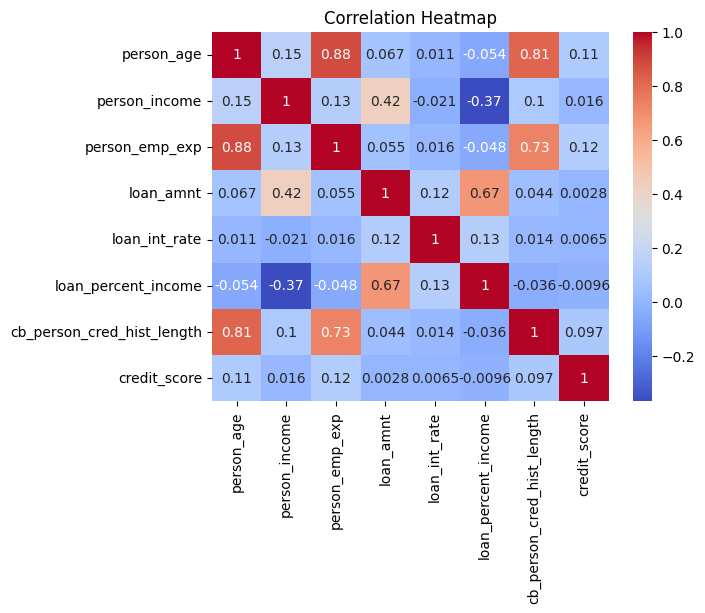

In [ ]:
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# **Strong Positive Correlations**
1, person_age ↔ person_emp_exp (0.88)

* Older individuals tend to have more work experience — this is expected.

2, person_age ↔ cb_person_cred_hist_length (0.81)

* As age increases, the credit history length also increases.

3, person_emp_exp ↔ cb_person_cred_hist_length (0.73)

* People with longer employment experience also tend to have longer credit histories.

4, loan_amnt ↔ loan_percent_income (0.67)

* Higher loan amounts consume a larger portion of a person’s income.

5, person_income ↔ loan_amnt (0.42)

* Higher-income individuals tend to take out larger loans, but this relationship is moderate.


# **Weak Correlation**
* credit_score has very weak correlation with all variables:

 * e.g., with income (0.016), loan amount (0.0028), and age (0.11)

 * This suggests credit scores are likely influenced by other factors not shown here (e.g., repayment history, number of defaults, etc.).

* loan_int_rate also has low correlations with most variables, indicating that:

 * The interest rate offered may not directly depend on income, loan amount, or age — possibly determined more by risk modeling or credit evaluation logic.





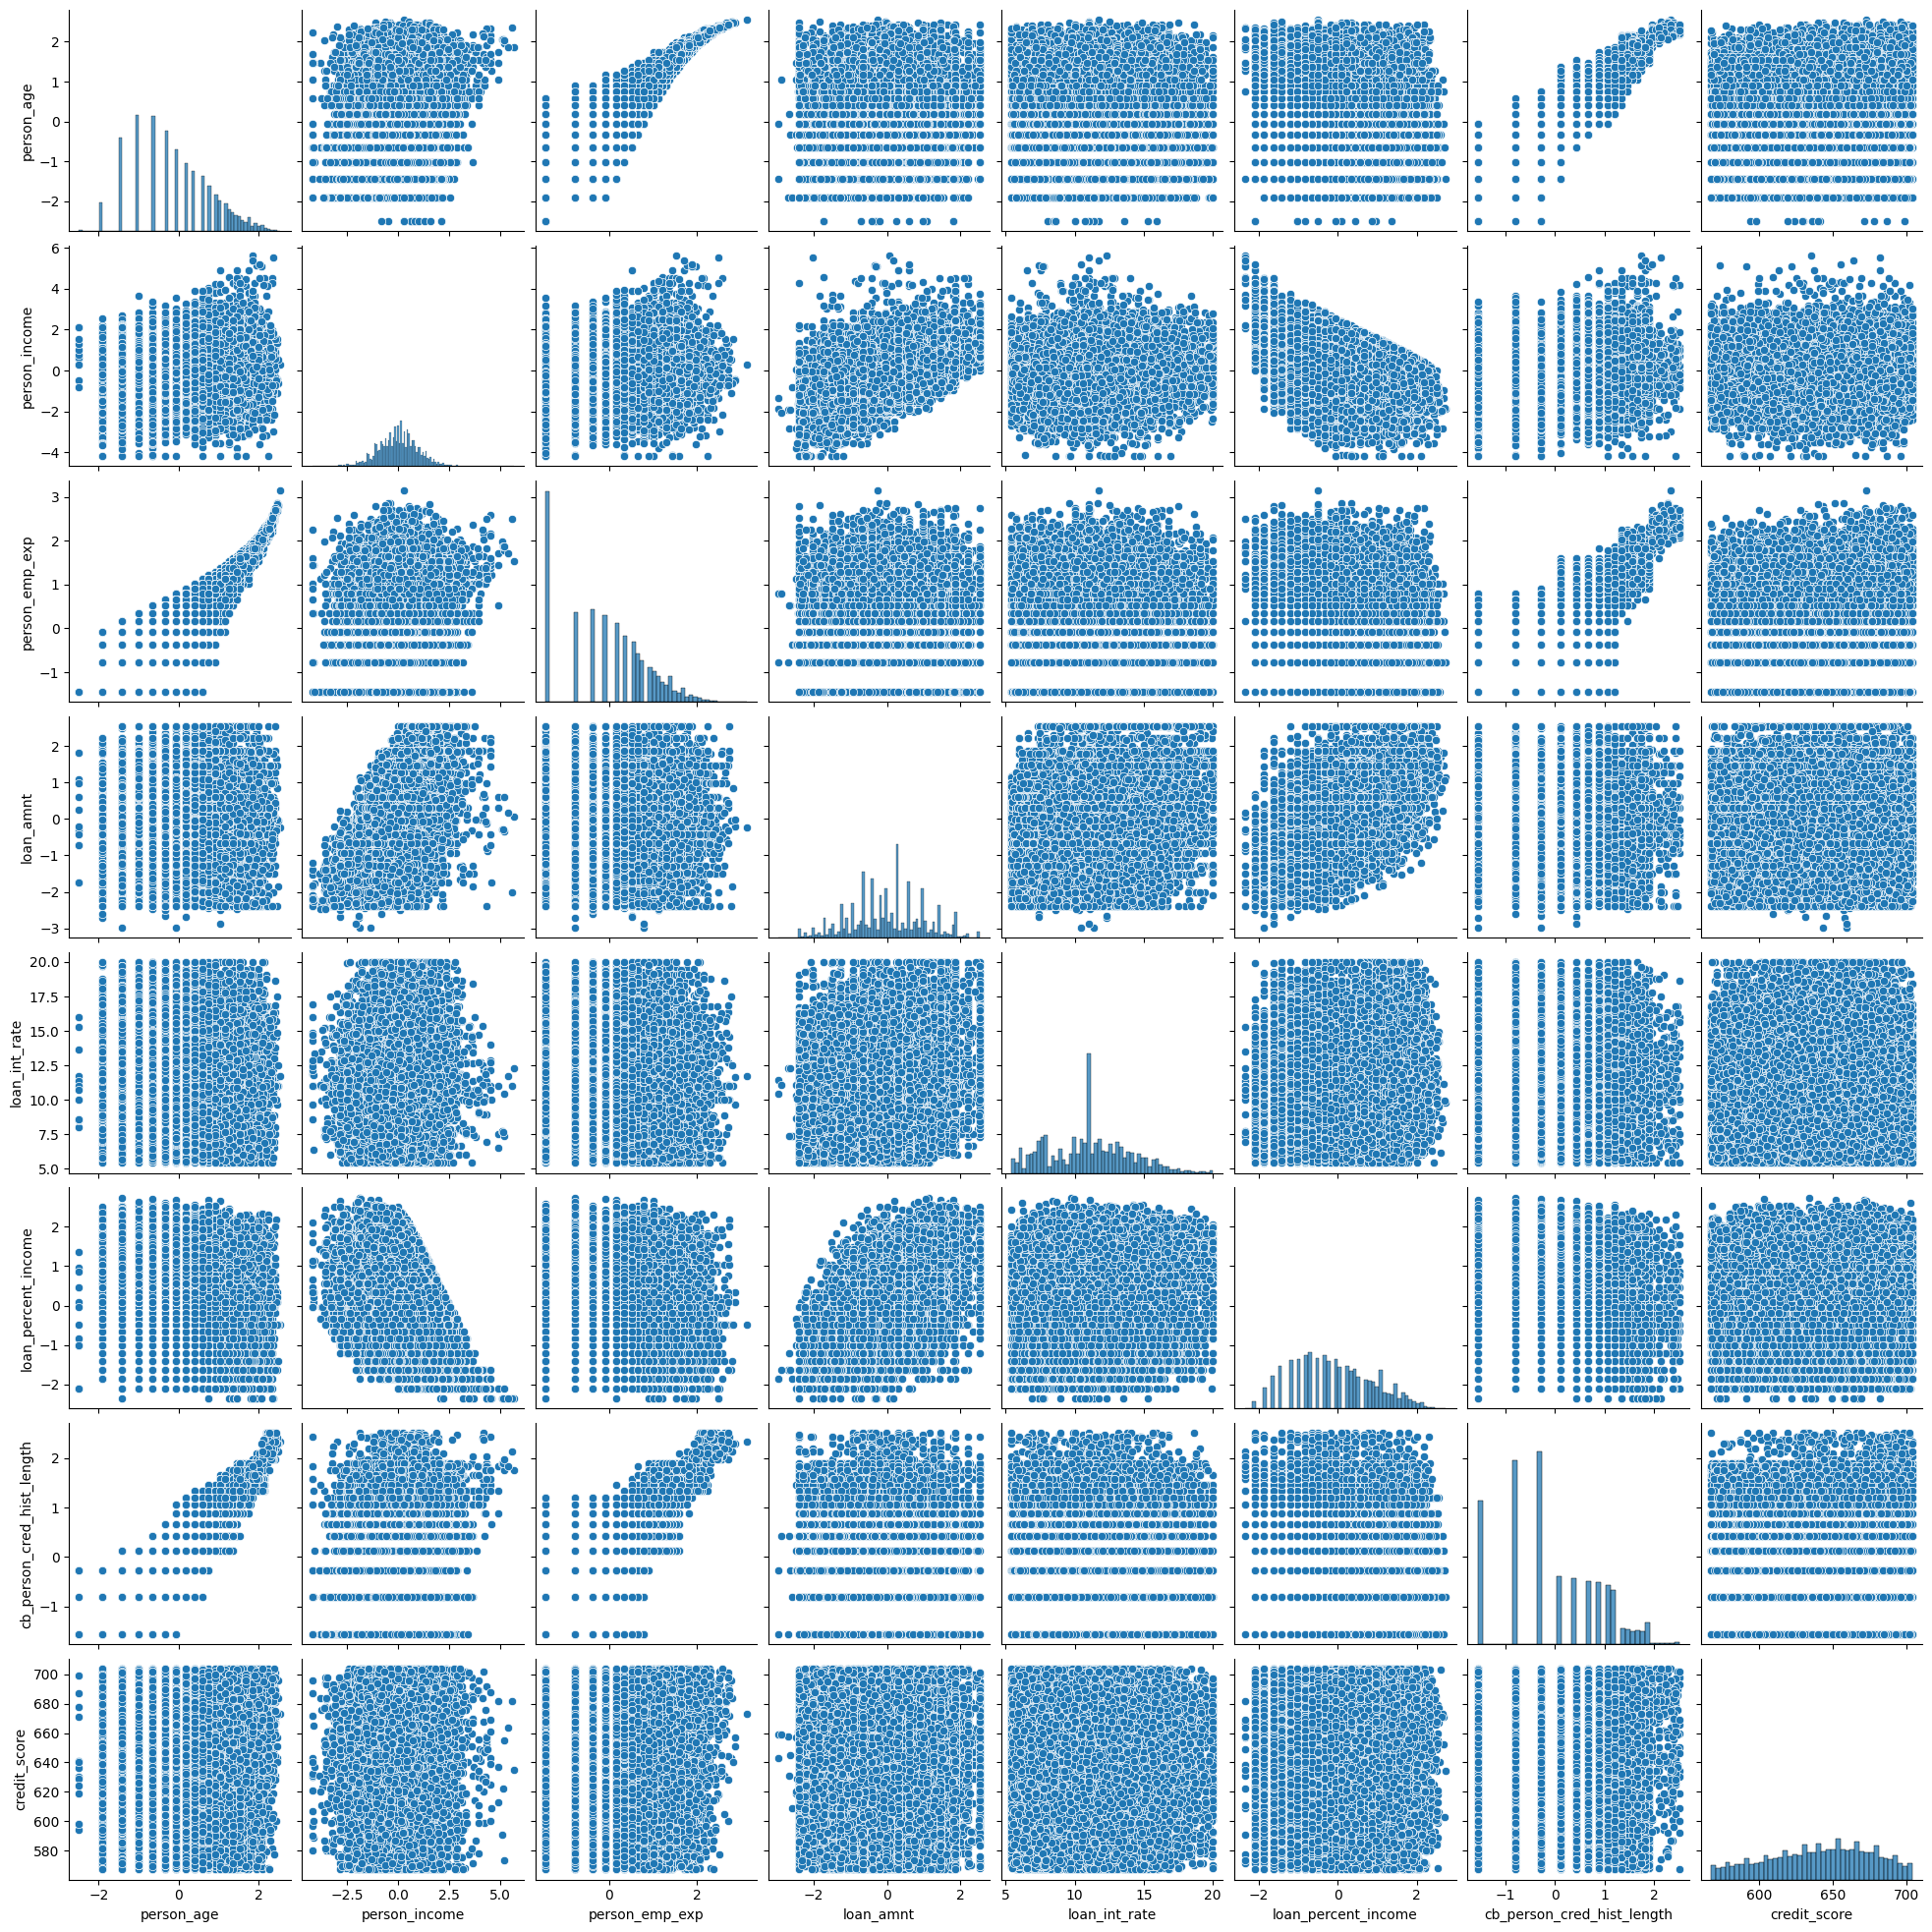

In [ ]:
sns.pairplot(data_cleaned.select_dtypes("number"))
plt.show()

# **Feature Engineering**

**1. Feature Encoding**

In [ ]:
#One hot encoding on Gender column
data_cleaned=pd.get_dummies(data_cleaned,columns=['person_gender'],dtype= int,drop_first=True)
data_cleaned.head(5)

,person_age,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_gender_male
2,-0.330442,High School,-3.262761,-0.077913,MORTGAGE,-0.534778,MEDICAL,12.87,2.243674,-0.796535,635,No,Yes,0
3,-1.007903,Bachelor,0.317259,-1.449481,RENT,2.533535,MEDICAL,15.23,2.243674,-1.555461,675,No,Yes,0
4,-0.645498,Master,-0.019096,-0.782465,RENT,2.533535,MEDICAL,14.27,2.496621,-0.271884,586,No,Yes,1
6,-0.055066,Bachelor,0.598334,-0.782465,RENT,2.533535,EDUCATION,12.42,1.974991,-0.796535,701,No,Yes,0
7,-0.645498,High School,0.637001,0.352462,RENT,2.533535,MEDICAL,11.11,1.974991,-0.271884,585,No,Yes,0


In [ ]:
#Ordinal Encoding on person_education column
from sklearn.preprocessing import OrdinalEncoder
edu_order=[['High School','Bachelor','Associate','Master','Doctorate']]
#Apply Ordinal encoder
encoder=OrdinalEncoder(categories=edu_order)
data_cleaned['person_education']=encoder.fit_transform(data_cleaned[['person_education']])
data_cleaned['person_education'] = data_cleaned['person_education'].astype(int)
data_cleaned.head(5)

,person_age,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_gender_male
2,-0.330442,0,-3.262761,-0.077913,MORTGAGE,-0.534778,MEDICAL,12.87,2.243674,-0.796535,635,No,Yes,0
3,-1.007903,1,0.317259,-1.449481,RENT,2.533535,MEDICAL,15.23,2.243674,-1.555461,675,No,Yes,0
4,-0.645498,3,-0.019096,-0.782465,RENT,2.533535,MEDICAL,14.27,2.496621,-0.271884,586,No,Yes,1
6,-0.055066,1,0.598334,-0.782465,RENT,2.533535,EDUCATION,12.42,1.974991,-0.796535,701,No,Yes,0
7,-0.645498,0,0.637001,0.352462,RENT,2.533535,MEDICAL,11.11,1.974991,-0.271884,585,No,Yes,0


In [ ]:
#One hot encoding on person_home_ownership column
data_cleaned=pd.get_dummies(data_cleaned,columns=['person_home_ownership'],dtype=int,drop_first=True)
data_cleaned.head(5)

,person_age,person_education,person_income,person_emp_exp,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_gender_male,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
2,-0.330442,0,-3.262761,-0.077913,-0.534778,MEDICAL,12.87,2.243674,-0.796535,635,No,Yes,0,0,0,0
3,-1.007903,1,0.317259,-1.449481,2.533535,MEDICAL,15.23,2.243674,-1.555461,675,No,Yes,0,0,0,1
4,-0.645498,3,-0.019096,-0.782465,2.533535,MEDICAL,14.27,2.496621,-0.271884,586,No,Yes,1,0,0,1
6,-0.055066,1,0.598334,-0.782465,2.533535,EDUCATION,12.42,1.974991,-0.796535,701,No,Yes,0,0,0,1
7,-0.645498,0,0.637001,0.352462,2.533535,MEDICAL,11.11,1.974991,-0.271884,585,No,Yes,0,0,0,1


In [ ]:
#One hot encoding on loan_intent column
data_cleaned=pd.get_dummies(data_cleaned,columns=['loan_intent'],dtype=int,drop_first=True)
data_cleaned.head(5)

,person_age,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_gender_male,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
2,-0.330442,0,-3.262761,-0.077913,-0.534778,12.87,2.243674,-0.796535,635,No,Yes,0,0,0,0,0,0,1,0,0
3,-1.007903,1,0.317259,-1.449481,2.533535,15.23,2.243674,-1.555461,675,No,Yes,0,0,0,1,0,0,1,0,0
4,-0.645498,3,-0.019096,-0.782465,2.533535,14.27,2.496621,-0.271884,586,No,Yes,1,0,0,1,0,0,1,0,0
6,-0.055066,1,0.598334,-0.782465,2.533535,12.42,1.974991,-0.796535,701,No,Yes,0,0,0,1,1,0,0,0,0
7,-0.645498,0,0.637001,0.352462,2.533535,11.11,1.974991,-0.271884,585,No,Yes,0,0,0,1,0,0,1,0,0


In [ ]:
#binary encoding on previous_loan_defaults_on_file column
data_cleaned['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0}).astype(int)
data_cleaned.head(5)

,person_age,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_gender_male,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
2,-0.330442,0,-3.262761,-0.077913,-0.534778,12.87,2.243674,-0.796535,635,0,Yes,0,0,0,0,0,0,1,0,0
3,-1.007903,1,0.317259,-1.449481,2.533535,15.23,2.243674,-1.555461,675,0,Yes,0,0,0,1,0,0,1,0,0
4,-0.645498,3,-0.019096,-0.782465,2.533535,14.27,2.496621,-0.271884,586,0,Yes,1,0,0,1,0,0,1,0,0
6,-0.055066,1,0.598334,-0.782465,2.533535,12.42,1.974991,-0.796535,701,0,Yes,0,0,0,1,1,0,0,0,0
7,-0.645498,0,0.637001,0.352462,2.533535,11.11,1.974991,-0.271884,585,0,Yes,0,0,0,1,0,0,1,0,0


**2. Feature Selection**

In [ ]:
#split the data
from sklearn.model_selection import train_test_split
X=data_cleaned.drop("loan_status",axis=1)
Y=data_cleaned["loan_status"]
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

from sklearn.ensemble import RandomForestClassifier
#Create a Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train,y_train)

# Get feature importances
importances = model.feature_importances_


# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(feature_importance_df)

                           Feature  Importance
9   previous_loan_defaults_on_file    0.213921
6              loan_percent_income    0.169243
5                    loan_int_rate    0.161173
2                    person_income    0.129117
4                        loan_amnt    0.058417
13      person_home_ownership_RENT    0.054843
8                     credit_score    0.049363
0                       person_age    0.031545
3                   person_emp_exp    0.028579
7       cb_person_cred_hist_length    0.025949
1                 person_education    0.017724
12       person_home_ownership_OWN    0.010252
15     loan_intent_HOMEIMPROVEMENT    0.010164
10              person_gender_male    0.008532
18             loan_intent_VENTURE    0.008173
14           loan_intent_EDUCATION    0.007912
16             loan_intent_MEDICAL    0.007501
17            loan_intent_PERSONAL    0.007013
11     person_home_ownership_OTHER    0.000580


In [ ]:
# Set a threshold (example: 0.01)
threshold = 0.01

# Select features with importance above the threshold
selected_features = feature_importance_df[feature_importance_df['Importance'] > threshold]

print("Selected Features:")
print(selected_features)

# If you want to use the selected features for your dataset X
X_selected = X[selected_features['Feature']]

Selected Features:
                           Feature  Importance
9   previous_loan_defaults_on_file    0.213921
6              loan_percent_income    0.169243
5                    loan_int_rate    0.161173
2                    person_income    0.129117
4                        loan_amnt    0.058417
13      person_home_ownership_RENT    0.054843
8                     credit_score    0.049363
0                       person_age    0.031545
3                   person_emp_exp    0.028579
7       cb_person_cred_hist_length    0.025949
1                 person_education    0.017724
12       person_home_ownership_OWN    0.010252
15     loan_intent_HOMEIMPROVEMENT    0.010164


In [ ]:
len(selected_features)

13

We got 13 selected features which has an importance above the threshold(0.01).

# **Split Data into Training and Testing Sets**

In [ ]:
X=data_cleaned.drop('loan_status',axis=1)
y=data_cleaned['loan_status']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(30352, 19)

In [ ]:
X_test.shape

(7588, 19)

In [ ]:
y_train.shape

(30352,)

In [ ]:
y_test.shape

(7588,)

# **Handling Class Imbalance**

In [ ]:
data_cleaned["loan_status"].value_counts()

,count
loan_status,
No,29516
Yes,8424


In [ ]:
#Calculate class imbalanced ratio
maj_class=data_cleaned["loan_status"].value_counts().max()
min_class=data_cleaned["loan_status"].value_counts().min()
ratio=maj_class/min_class
print(f"Class Imbalance Ratio:{ratio:.2f}")

Class Imbalance Ratio:3.50


We have got an imbalance ratio 3.50, which indicates the data is properly unbalanced. So we  need to  apply smote technique to balance it.


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
# Check class distribution
print("Before SMOTE:", Counter(y_train))

# Apply SMOTE
smote = SMOTE(sampling_strategy='auto',random_state=42)
X_resampled,y_resampled = smote.fit_resample(x_train, y_train)

# Check new class distribution
print("After SMOTE:", Counter(y_resampled))

Before SMOTE: Counter({'No': 23629, 'Yes': 6723})
After SMOTE: Counter({'No': 23629, 'Yes': 23629})


# **Feature Scaling using Standard Scalar**

In [ ]:
#Binary columns should not be scaled
# Identify Binary Columns (Columns with Only 2 Unique Values)
binary_cols = [col for col in data_cleaned.columns if data_cleaned[col].nunique() == 2]
# Identify non-binary numeric columns
numeric_cols=data_cleaned.select_dtypes(include=['float64', 'int64']).columns
non_binary_cols=[col for col in numeric_cols if col not in binary_cols]
#Apply Standard Scalar only to non binary columns
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
# Convert x_train_resampled back to DataFrame
X_train_resampled_df = pd.DataFrame(X_resampled,columns=X.columns)
y_train_resampled_df = pd.Series(y_resampled, name='loan_status')
x_train_scaled=scaler.fit_transform(X_resampled[non_binary_cols])
x_test_scaled=scaler.fit_transform(X_test[non_binary_cols])

print("Original class distribution:\n", y.value_counts())
print("Resampled class distribution:\n", y_train_resampled_df.value_counts())

Original class distribution:
 loan_status
No     29516
Yes     8424
Name: count, dtype: int64
Resampled class distribution:
 loan_status
No     23629
Yes    23629
Name: count, dtype: int64


<ipython-input-46-1bd5b8fce79d>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y.value_counts().index, y=y.value_counts().values, palette="viridis", ax=axes[0])
<ipython-input-46-1bd5b8fce79d>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y_train_resampled_df.value_counts().index, y=y_train_resampled_df.value_counts().values, palette="viridis", ax=axes[1])


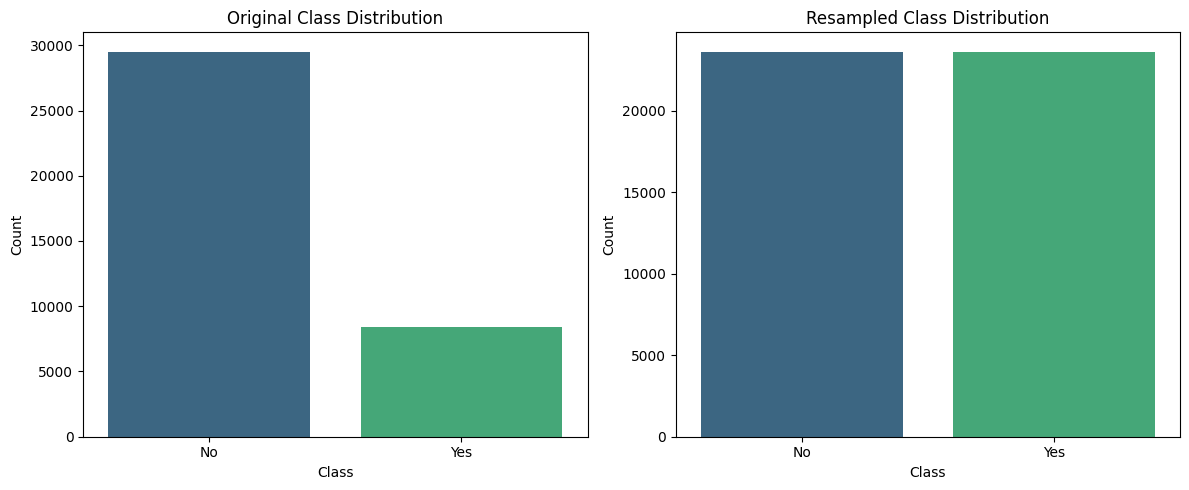

In [ ]:
# Plot original vs resampled class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original class distribution
sns.barplot(x=y.value_counts().index, y=y.value_counts().values, palette="viridis", ax=axes[0])
axes[0].set_title("Original Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# Resampled class distribution
sns.barplot(x=y_train_resampled_df.value_counts().index, y=y_train_resampled_df.value_counts().values, palette="viridis", ax=axes[1])
axes[1].set_title("Resampled Class Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

After resampling both classes are now balanced

# **Basic Model Building**

Models
1. Logistic Regression – A linear model used for binary classification, estimating the probability of a class using the logistic function.
2. Random Forest – An ensemble learning method that builds multiple decision trees and combines their outputs for better accuracy and robustness.
3. Gradient Boosting – A boosting technique that sequentially improves weak learners (decision trees) by minimizing errors,often leading to high accuracy.
4. Decision Tree – A tree-based model that splits data based on feature conditions,making it easy to interpret but prone to overfitting.
5. K-Nearest Neighbors (KNN) – A non-parametric algorithm that classifies a data point based on the majority class of its nearest neighbors.

In [ ]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

models = {
    'Logistic Regression': LogisticRegression(solver='liblinear'),# To avoid convergence warnings
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}
results = {} #Stores results for each model
for name,model in models.items(): #iterate through model dictionary
    model.fit(X_train,y_train) # Train model on Traning data
    y_test_pred = model.predict(X_test) #predict on test data
    y_train_pred = model.predict(X_train) # predict on train data

    train_accuracy = accuracy_score(y_train,y_train_pred)
    test_accuracy = accuracy_score(y_test,y_test_pred)

    print(f"{name}:")
    print(f"Training Accuracy:{train_accuracy: .3f}")
    print(f"Testing Accuracy:{test_accuracy: .3f}")

Logistic Regression:
Training Accuracy: 0.892
Testing Accuracy: 0.890
Random Forest:
Training Accuracy: 1.000
Testing Accuracy: 0.927
Gradient Boosting:
Training Accuracy: 0.924
Testing Accuracy: 0.921
Decision Tree:
Training Accuracy: 1.000
Testing Accuracy: 0.896
K-Nearest Neighbors:
Training Accuracy: 0.896
Testing Accuracy: 0.848


In [ ]:
# Dictionary to store results
results = {}
# Loop through each model and train it
for name, model in models.items():
    model.fit(X_train,y_train) # Train the model
    y_pred = model.predict(X_test) # Make predictions on the test set

    # Compute evaluation metrics
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred, pos_label='Yes')  # Specify pos_label
    recall = recall_score(y_test,y_pred, pos_label='Yes')  # Specify pos_label
    f1 = f1_score(y_test,y_pred, pos_label='Yes')  # Specify pos_label

    # Store results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
    }

# Convert results to DataFrame and display
results_df = pd.DataFrame(results).T

# Sort the DataFrame by the 'Accuracy' column in descending order
results_df_sorted = results_df.sort_values(by=["Accuracy"],ascending=False)

# Display the sorted DataFrame
results_df_sorted

,Accuracy,Precision,Recall,F1-Score
Random Forest,0.925145,0.885112,0.765432,0.820933
Gradient Boosting,0.921060,0.867824,0.764256,0.812754
Decision Tree,0.895756,0.760894,0.780129,0.770392
Logistic Regression,0.889826,0.758209,0.746620,0.752370
K-Nearest Neighbors,0.847918,0.714174,0.536155,0.612492


# **📝Insights**

# Random Forest Performs Best Overall:
  * Accuracy (0.925): Highest among all models, indicating it correctly
  classifies the most instances.
  * F1-Score (0.820): Also the highest, balancing precision and recall
  effectively, making it the most reliable model for this task.
  * Precision (0.883): Strong ability to minimize false positives.
  * Recall (0.766): Good at identifying positive cases, though slightly lower than Decision Tree.
# Gradient Boosting is a Close Second:
  * Accuracy (0.921): Nearly as good as Random Forest.
  * F1-Score (0.813): Slightly lower than Random Forest but still strong.
  * Precision (0.868) and Recall (0.764): Comparable to Random Forest, indicating robust performance but marginally less effective.
# Decision Tree Balances Recall and Accuracy:
  * Accuracy (0.895): Lower than Random Forest and Gradient Boosting.
  * Recall (0.777): Highest among all models, meaning it’s best at capturing positive cases.
  * Precision (0.759): Lower than Random Forest and Gradient Boosting, suggesting more false positives.
  * F1-Score (0.768): Decent but lags behind top performers due to lower precision.
# Logistic Regression is Solid but Not Outstanding:
  * Accuracy (0.888): Respectable but outperformed by Random Forest, Gradient Boosting, and Decision Tree.
  * F1-Score (0.748): Lower than the top three, indicating a weaker balance between precision and recall.
  * Precision (0.754) and Recall (0.743): Balanced but not exceptional, suitable for simpler tasks.
# K-Nearest Neighbors (KNN) Underperforms:
  * Accuracy (0.848): Lowest among all models.
  * F1-Score (0.612): Significantly lower, indicating poor overall performance.
  * Recall (0.536): Very low, meaning it misses many positive cases.
  * Precision (0.714): Moderate, but not enough to compensate for low recall.

In [ ]:
best_model = results_df['Accuracy'].idxmax()
print(f'The best Model based on Accuracy is:\n {best_model}')
print(results_df.loc[best_model])

The best Model based on Accuracy is:
 Random Forest
Accuracy     0.925804
Precision    0.886549
Recall       0.767196
F1-Score     0.822565
Name: Random Forest, dtype: float64


# **Hyperparameter Tuning**
 Hyperparameter tuning is the process of selecting the best set of hyperparameters to optimize a machine learning model's performance. Unlike model parameters (learned from data), hyperparameters are set manually before training.

* Improves Accuracy – Finds the best settings for better predictions.

* Prevents Overfitting/Underfitting – Balances model complexity.

* Enhances Generalization – Ensures the model works well on unseen data.

* GridSearchCV, RandomizedSearchCV, and Bayesian Optimization are some methods for hyperparameter tuning.

* Since hyperparameter tuning is time-consuming, it's better to focus on models that show promising performance. Here, we only perform hyperparameter tuning on Random Forest.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

# Define the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameters to tune
rf_params = {
    'n_estimators': [100, 200],  # Number of trees
    'max_depth': [10, 20],  # Maximum depth of trees
    'min_samples_split': [2, 5],  # Minimum samples to split an internal node
    'min_samples_leaf': [1, 2],  # Minimum samples in a leaf node
    'max_features': ['sqrt'],  # Number of features considered for split
    'bootstrap': [True]  # Whether to use bootstrapping
}

# Perform RandomizedSearchCV
rf_random = RandomizedSearchCV(rf, rf_params, cv=5, n_jobs=2, verbose=2)
rf_random.fit(X_train, y_train)

# Get the best model, best parameters, and accuracy
best_rf = rf_random.best_estimator_
best_rf_params = rf_random.best_params_
rf_accuracy = accuracy_score(y_test, best_rf.predict(X_test))

# Print results
print(f"Best Random Forest Model: {best_rf}")
print(f"Best Parameters: {best_rf_params}")
print(f"Accuracy: {rf_accuracy:.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Random Forest Model: RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=200,
                       random_state=42)
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}
Accuracy: 0.9232


In [ ]:
#  Evaluate on test data
y_pred = best_rf.predict(X_test)

#  Display performance metrics
print("\n Optimized Random Forest Performance:")
print(f" Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f" Precision: {precision_score(y_test, y_pred,pos_label='Yes'):.4f}")
print(f" Recall: {recall_score(y_test, y_pred,pos_label='Yes'):.4f}")
print(f" F1 Score: {f1_score(y_test, y_pred,pos_label='Yes'):.4f}")


 Optimized Random Forest Performance:
 Accuracy: 0.9232
 Precision: 0.8798
 Recall: 0.7613
 F1 Score: 0.8163


#  **Save the Model**

In [ ]:
import joblib
joblib.dump(best_model,"loan_prediction.joblib")
print("model saved successfully")

model saved successfully


#  **Pipeline**



A machine learning pipeline was implemented to automate data preprocessing, feature selection, and model training, ensuring efficiency and reproducibility.

* Data Preprocessing: Missing values were handled using an imputer, and feature scaling was applied for consistency.

* Feature Selection: Mutual Information (SelectKBest) was used to select the most relevant features.

* Handling Imbalanced Data: SMOTE was applied to balance class distribution.

* Model Training: Random Forest was chosen as the final model after hyperparameter tuning.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Define the pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', best_rf)  # Use the best Random Forest model
])

# Train the pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(max_depth=20, min_samples_split=5,
                                        n_estimators=200, random_state=42))])

In [ ]:
# Saving the Pipeline
joblib.dump(pipeline, 'pipeline.joblib')
print("Pipeline saved successfully!")

Pipeline saved successfully!


#  **Test WIth Unseen Data**

In [ ]:
# Randomly sample 20 rows from the dataset
unseen_data = data_cleaned.sample(n=20, random_state=42)

# Display the unseen data
unseen_data


,person_age,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_gender_male,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
17033,-1.007903,3,-0.760767,-1.449481,-0.941726,10.99,-0.491933,-0.796535,616,0,Yes,0,0,0,1,0,0,0,1,0
38124,-1.427213,0,-0.483110,-0.375018,0.946993,13.18,1.555326,-0.271884,667,0,No,1,0,0,0,1,0,0,0,0
33595,-1.007903,0,-0.164352,-1.449481,-0.418229,10.90,-0.335086,-0.796535,616,0,No,0,0,0,1,0,0,0,1,0
43282,1.372778,3,-0.625980,1.120881,0.315832,12.36,0.958608,0.675077,642,0,Yes,1,0,0,1,0,0,1,0,0
14867,-0.645498,0,1.328302,-0.077913,1.276088,17.04,0.090050,-0.796535,604,0,No,0,0,0,0,0,0,0,0,1
32053,1.686994,2,2.210401,1.523186,0.789664,11.49,-1.014811,1.831841,605,1,No,0,0,0,1,0,0,0,0,1
26263,0.757894,2,0.353752,0.796844,0.849369,12.84,0.566261,0.882646,639,1,No,0,0,0,1,1,0,0,0,0
42447,-1.007903,2,-0.352309,-0.375018,0.964037,10.52,1.425679,-0.271884,646,0,Yes,1,0,0,1,0,0,0,0,0
6200,-0.330442,1,-1.305023,-0.782465,-0.418229,11.86,0.671477,-0.796535,621,0,No,0,0,0,1,0,0,0,0,1
14546,-1.427213,3,-0.526155,-1.449481,-1.729567,6.62,-1.412812,-0.796535,687,1,No,1,0,0,1,1,0,0,0,0


In [ ]:
unseen_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 17033 to 10540
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      20 non-null     float64
 1   person_education                20 non-null     int64  
 2   person_income                   20 non-null     float64
 3   person_emp_exp                  20 non-null     float64
 4   loan_amnt                       20 non-null     float64
 5   loan_int_rate                   20 non-null     float64
 6   loan_percent_income             20 non-null     float64
 7   cb_person_cred_hist_length      20 non-null     float64
 8   credit_score                    20 non-null     int64  
 9   previous_loan_defaults_on_file  20 non-null     int64  
 10  loan_status                     20 non-null     object 
 11  person_gender_male              20 non-null     int64  
 12  person_home_ownership_OTHER     20 n

In [ ]:
# Load the best model from a file
model_filename = 'pipeline.joblib'
loaded_model = joblib.load(model_filename)

In [ ]:
unseen_data_for_prediction = unseen_data.drop(columns=['loan_status'])
# Make predictions on unseen data
predictions = loaded_model.predict(unseen_data_for_prediction)

# Output predictions
print("Predictions on Unseen Data:", predictions)

Predictions on Unseen Data: ['No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No'
 'Yes' 'No' 'Yes' 'No' 'No' 'Yes']


 **Insights**

This means that out of the 10 rows of unseen data, the model predicts that:

Yes → Model predicts that the loan application is approved.

No → Model predicts that the loan application is rejected.

# **Conclusion**

  

The project on **Loan Approval Prediction** aimed to develop a machine learning model to predict whether a loan application would be approved or rejected based on various customer and financial parameters. By analyzing factors such as credit history, income, loan amount, employment status, and other relevant features, we successfully built and evaluated multiple classification models, including **Logistic Regression, Decision Trees, Random Forest,K-Nearest Neighbors (KNN) and Gradient Boosting**.  

After thorough data preprocessing, feature engineering, and hyperparameter tuning, the **Random Forest  demonstrated the highest accuracy and precision**, making  the most reliable for loan approval predictions. The model's performance was validated using metrics such as **accuracy, precision, recall and F1-score,** ensuring robustness in real-world scenarios.  

This predictive system can significantly benefit **banks and financial institutions** by automating the loan approval process, reducing human bias, and improving decision-making efficiency. Future enhancements could include integrating **more dynamic features, deploying the model as a web application, or using deep learning techniques** for even better accuracy.  

In conclusion, this project successfully demonstrates the potential of **machine learning in financial risk assessment**, providing a scalable and efficient solution for loan approval predictions.

 # **Future Work**

* **Deep Learning Exploration**: Investigate deep learning algorithms, such as neural networks, for potentially higher accuracy and capturing more complex patterns in the data.
* **Model Updates**: Periodically update the model with new data to ensure it adapts to changing trends and behaviors over time.
* **Imbalanced Data Handling**: Implement resampling techniques, like oversampling or undersampling, to address any class imbalances in the dataset, ensuring the model is not biased.
* **Feature Engineering**: Consider adding more features or engineering existing ones to capture more nuanced patterns that could enhance the model's predictive power.

# **Best Model:**
 The Random Forest Classifier model, with an accuracy of 92 %, has been saved as The_Best_Model.joblib for future use.